# VIX Futures Basis Strategy — Futures Backtest
### Replication and extension of Simon & Campasano (2014), *The VIX Futures Basis: Evidence and Trading Strategies*

**Idea.** The VIX futures basis (F − VIX) does not forecast changes in spot VIX. Because futures must converge to spot at settlement, the basis instead forecasts **futures** price changes. Futures roll down the curve in contango and up the curve in backwardation. That roll is harvested with VX futures, and the equity beta of the position is hedged with E-mini S&P 500 futures.

**Trading rules (paper, Section III)**

| Item | Rule |
|---|---|
| Instrument | Nearest VX future with **≥ 10 business days** to settlement |
| Daily roll | (F − VIX) / business days to settlement |
| Short entry | daily roll **> +0.10** (contango) → sell 1 VX, sell HR × ES |
| Long entry | daily roll **< −0.10** (backwardation) → buy 1 VX, buy HR × ES |
| Exit | short: roll < +0.05 · long: roll > −0.05 · or after **9 business days** |
| Re-entry | from the day after an exit |
| Hedge ratio | Eq. (3) `ΔF_t = b0 + b1·SPRET_t + b2·SPRET_t·TTS_{t-1}`, expanding-window OLS from 2006 through t−1; HR = (b1 + b2·TTS)·1000 / (0.01·ES·50). Fixed for the life of the trade |
| Costs | full VX spread paid, ES half-tick ($6.25) per side, $3 round-trip brokerage per contract (≈ $140 per round trip in the paper) |
| Sample | Jan 2007 – Dec 2011 (halves: 1/07–6/09 and 7/09–12/11) |

**Notebook structure**

1. Setup and configuration  
2. Data: VX contracts (CBOE files from `getvix_data.R`), VIX spot, E-mini S&P  
3. Daily panel: F1/F2, traded contract, business days to settlement, daily roll  
4. Replication of Exhibits 1–3 (descriptives, regimes, daily roll)  
5. Replication of Exhibit 4 (predictive regressions)  
6. Hedge-ratio model: Eq. (3) and (4), expanding-window out-of-sample  
7. Backtest engine (trade level and daily mark-to-market)  
8. Replication of Exhibits 5–8, including random-entry bootstrap p-values and margin-based returns  
9. Extension to the full sample (2007 → today): yearly results, stress episodes, drawdowns  
10. Robustness: thresholds, holding period, execution lag, costs, contract choice, hedge-estimation window, in-sample hedge  
11. Hedge effectiveness  
12. Summary and caveats

**Data differences vs. the paper.** The paper uses synchronized CQG intraday quotes, with the first quote after 3:00 pm CT whose spread is ≤ 0.10, and pays the observed spread. This notebook uses **CBOE daily settlement prices**, the **VIX close**, and **ES daily closes**. Spreads are therefore *modelled* rather than observed (see `VX_COST_PER_SIDE`), and small timing mismatches between the three closes remain.

## 1. Setup

In [4]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import statsmodels.api as sm
from dateutil.easter import easter
from pandas.tseries.holiday import USFederalHolidayCalendar
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 100, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

try:
    import yfinance as yf
except ImportError:
    yf = None
    print('yfinance not installed -> `pip install yfinance` or set ES_SOURCE = "csv"')

print('pandas', pd.__version__, '| statsmodels', sm.__version__)

pandas 2.2.2 | statsmodels 0.15.0


## 2. Configuration
All tunable choices live in this cell. The defaults reproduce the paper's rules.

In [5]:
# ---------------------------------------------------------------- paths
DATA_DIR = 'data'
VX_DIR   = os.path.join(DATA_DIR, 'vix_futures')            # output folder of getvix_data.R
VIX_SPOT_CANDIDATES = [os.path.join(DATA_DIR, 'VIX_History.csv'),   # name used by the R script
                       os.path.join(DATA_DIR, 'vix_history.csv')]   # name used in the v4 notebook

# ---------------------------------------------------------------- E-mini S&P 500 source
# 'yfinance': ES=F (unadjusted continuous front month). Roll-day jumps are cleaned with ^GSPC returns.
# 'csv'     : your own series (e.g. Bloomberg ES1 Index, roll-adjusted), columns: date, close
ES_SOURCE        = 'yfinance'
ES_TICKER        = 'ES=F'
SPX_TICKER       = '^GSPC'
ES_CSV_PATH      = os.path.join(DATA_DIR, 'es_futures.csv')
ES_ROLL_CLEAN_TOL = 0.004   # |r_ES - r_SPX| above this => treat as roll gap, replace with r_SPX
CLEAN_CSV_ES     = False    # also apply the roll cleaning to a CSV series

# The paper estimates hedge ratios from 2006 onward. getvix_data.R starts with contracts
# expiring in 2007, so the 2006 front months are missing. This option tries to download them.
DOWNLOAD_MISSING_2006 = True

# ---------------------------------------------------------------- samples
HEDGE_EST_START = '2006-01-01'   # start of the expanding hedge-ratio regression
REG_START       = '2006-01-01'   # Exhibit 4 regressions
PAPER_START, PAPER_END = '2007-01-01', '2011-12-31'
PAPER_H1_END,  PAPER_H2_START = '2009-06-30', '2009-07-01'
FULL_END        = None           # None = last available date

# ---------------------------------------------------------------- strategy (paper defaults)
PARAMS = dict(
    entry_short = 0.10,   # enter short when daily roll >  +0.10
    entry_long  = 0.10,   # enter long  when daily roll <  -0.10
    exit_short  = 0.05,   # exit short  when daily roll <  +0.05
    exit_long   = 0.05,   # exit long   when daily roll >  -0.05
    max_hold    = 9,      # business days
    min_tts     = 10,     # min business days to settlement of the traded contract
    exec_lag    = 0,      # 0 = trade at the close the signal is observed (paper); 1 = next close
    same_day_reentry = False,
    n_vx        = 1,      # VX contracts per trade
)

# ---------------------------------------------------------------- contract specs & costs
VX_MULT, ES_MULT = 1000, 50
VX_COST_PER_SIDE  = 0.06    # VX points paid per side (paper: full quoted spread ~0.062 on entry AND exit)
VX_COST_VIX_SCALE = False   # True: cost_side * max(1, VIX/20) -> wider spreads in stress
ES_COST_PER_SIDE  = 0.125   # ES points per side (half of the 0.25 tick = $6.25)
BROKERAGE_RT      = 3.0     # $ per contract, round trip
MIN_VX_PRICE      = 5.0     # drop obviously broken settles
VX_RESCALE_DATE   = '2007-03-26'  # before this date VX was quoted as 10x VIX

# ---------------------------------------------------------------- hedge model
HEDGE_MIN_OBS = 120        # min observations before a hedge ratio is produced
HEDGE_WINDOW  = None       # None = expanding (paper); int = rolling window in days

# ---------------------------------------------------------------- inference & capital
N_BOOT = 10_000
SEED   = 42
MARGIN_VX, MARGIN_ES = 6_900, 4_375     # margins quoted in the paper
EQUITY_MULTIPLE = 5                     # "realistic" capital = 5x margin (paper)

STRESS_EVENTS = {'Lehman': '2008-09-15', 'Flash crash': '2010-05-06', 'US downgrade': '2011-08-08',
                 'Volmageddon': '2018-02-05', 'COVID': '2020-03-16', 'Yen carry unwind': '2024-08-05',
                 'Tariff shock': '2025-04-07'}

# ---------------------------------------------------------------- paper reference numbers (Exhibits 5 & 8)
PAPER_EX5 = {
    'Short': {'Hedged': dict(mean=792,  p=0.003, semi=631,  p90=3282, p10=-1045, wl='40/22', dur=6.4, sortino=1.26),
              'Unhedged': dict(mean=861, p=0.018, semi=975, p90=4197, p10=-1973, wl='38/24', sortino=0.88),
              'S&P Hedge': dict(mean=-69, semi=843, p90=1164, p10=-1316, wl='29/33'),
              'Roll': dict(mean=831, p90=1557, p10=70)},
    'Long':  {'Hedged': dict(mean=1018, p=0.001, semi=990,  p90=4522, p10=-1539, wl='19/21', dur=4.3, sortino=1.03),
              'Unhedged': dict(mean=1406, p=0.001, semi=1446, p90=7747, p10=-2683, wl='26/24', sortino=0.97),
              'S&P Hedge': dict(mean=-387, semi=2628, p90=2128, p10=-2996, wl='23/17'),
              'Roll': dict(mean=1333, p90=4283, p10=60)},
}
PAPER_EX8 = {  # mean hedged P&L, p-value, Sortino, #trades
    ('Short', '1/07-6/09'): (991, 0.009, 1.97, 19), ('Short', '7/09-12/11'): (704, 0.074, 1.04, 43),
    ('Long',  '1/07-6/09'): (1211, 0.014, 1.00, 23), ('Long',  '7/09-12/11'): (757, 0.006, 1.29, 17),
}
print('Config loaded.')

Config loaded.


## 3. Trading calendar and VX settlement dates

**VX final settlement date.** The Wednesday 30 days before the third Friday of the following month. If that Friday is an exchange holiday, count 30 days back from the business day before it (e.g. Feb-2008 → 2008-02-19, Mar-2014 → 2014-03-18). If the Wednesday itself is a holiday, use the preceding business day.

**Business days to settlement (TTS).** The number of trading days in (t, expiry]. Inside the data range, the trading calendar is the set of dates on which VX data exist. Beyond the last data point, an approximate NYSE holiday calendar is used.

In [6]:
MONTH_CODES = dict(F=1, G=2, H=3, J=4, K=5, M=6, N=7, Q=8, U=9, V=10, X=11, Z=12)
SPECIAL_CLOSURES = pd.to_datetime(['2004-06-11', '2007-01-02', '2012-10-29', '2012-10-30',
                                   '2018-12-05', '2025-01-09'])

def approx_exchange_holidays(start='2000-01-01', end='2030-12-31'):
    fed = USFederalHolidayCalendar().holidays(start, end, return_name=True)
    fed = fed[~fed.str.contains('Columbus|Veterans')].index      # equity markets are open on these
    gf  = pd.to_datetime([pd.Timestamp(easter(y)) - pd.Timedelta(days=2)
                          for y in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1)])
    return pd.DatetimeIndex(fed).union(gf).union(SPECIAL_CLOSURES)

HOLIDAYS = approx_exchange_holidays()

def _prev_bday(d, hol):
    d = d - pd.Timedelta(days=1)
    while d.weekday() >= 5 or d in hol:
        d -= pd.Timedelta(days=1)
    return d

def vx_settlement_date(year, month, hol=HOLIDAYS):
    ny, nm = (year + 1, 1) if month == 12 else (year, month + 1)
    first = pd.Timestamp(ny, nm, 1)
    third_fri = first + pd.Timedelta(days=(4 - first.weekday()) % 7 + 14)
    if third_fri in hol:
        third_fri = _prev_bday(third_fri, hol)
    exp = third_fri - pd.Timedelta(days=30)
    if exp.weekday() >= 5 or exp in hol:
        exp = _prev_bday(exp, hol)
    return exp

# sanity checks against dates in getvix_data.R
for (y, m), ref in {(2013, 1): '2013-01-16', (2014, 3): '2014-03-18', (2019, 3): '2019-03-19',
                    (2022, 3): '2022-03-15', (2024, 6): '2024-06-18', (2026, 5): '2026-05-19'}.items():
    got = vx_settlement_date(y, m).date()
    print(f'{y}-{m:02d}: computed {got}  reference {ref}  {"OK" if str(got) == ref else "MISMATCH"}')

2013-01: computed 2013-01-16  reference 2013-01-16  OK
2014-03: computed 2014-03-18  reference 2014-03-18  OK
2019-03: computed 2019-03-19  reference 2019-03-19  OK
2022-03: computed 2022-03-15  reference 2022-03-15  OK
2024-06: computed 2024-06-18  reference 2024-06-18  OK
2026-05: computed 2026-05-19  reference 2026-05-19  OK


## 4. Load VX futures contracts

The reader handles the two CBOE layouts written by `getvix_data.R`:

* `CFE_<code><yy>_VX.csv`: archive files (≤ 2012). The settlement date comes from the calendar rule and is cross-checked against the last trade date in the file.
* `VX_<YYYY-MM-DD>.csv`: current files (≥ 2013). The settlement date is taken from the file name.

Cleaning steps:

* Prices before **2007-03-26** are divided by 10 (the old contract was quoted on 10 × VIX).
* Missing or zero settles fall back to the close.
* Settles below `MIN_VX_PRICE` are dropped.
* Rows after the settlement date are dropped.

The optional cell first tries to download the 2006 contracts, which the paper needs for the hedge-ratio burn-in.

In [7]:
if DOWNLOAD_MISSING_2006:
    import urllib.request
    os.makedirs(VX_DIR, exist_ok=True)
    base = 'https://cdn.cboe.com/resources/futures/archive/volume-and-price/'
    for code_ in MONTH_CODES:
        fn = f'CFE_{code_}06_VX.csv'
        dest = os.path.join(VX_DIR, fn)
        if os.path.exists(dest):
            continue
        try:
            req = urllib.request.Request(base + fn, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=20) as r, open(dest, 'wb') as fh:
                fh.write(r.read())
            print('downloaded', fn)
        except Exception as e:
            print('not available', fn, '->', type(e).__name__)

downloaded CFE_F06_VX.csv
downloaded CFE_G06_VX.csv
downloaded CFE_H06_VX.csv
downloaded CFE_J06_VX.csv
downloaded CFE_K06_VX.csv
downloaded CFE_M06_VX.csv
downloaded CFE_N06_VX.csv
downloaded CFE_Q06_VX.csv
downloaded CFE_U06_VX.csv
downloaded CFE_V06_VX.csv
downloaded CFE_X06_VX.csv
downloaded CFE_Z06_VX.csv


In [8]:
def settlement_from_filename(path):
    base = os.path.basename(path)
    m = re.match(r'VX_(\d{4}-\d{2}-\d{2})\.csv$', base)
    if m:
        return pd.Timestamp(m.group(1)), 'filename'
    m = re.match(r'CFE_([A-Z])(\d{2})_VX\.csv$', base)
    if m and m.group(1) in MONTH_CODES:
        return vx_settlement_date(2000 + int(m.group(2)), MONTH_CODES[m.group(1)]), 'rule'
    return None, None

def read_cboe_file(path):
    with open(path, 'r', errors='ignore') as fh:
        lines = fh.readlines()
    hdr = next((i for i, l in enumerate(lines) if 'Trade Date' in l), None)
    if hdr is None:
        return None
    df = pd.read_csv(path, skiprows=hdr)
    df.columns = df.columns.str.strip()
    df = df.dropna(subset=['Trade Date'])
    first = str(df['Trade Date'].iloc[0])
    fmt = '%m/%d/%Y' if '/' in first else '%Y-%m-%d'
    df['date'] = pd.to_datetime(df['Trade Date'].astype(str).str.strip(), format=fmt, errors='coerce')
    ren = {'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close', 'Settle': 'settle',
           'Total Volume': 'volume', 'Open Interest': 'oi'}
    df = df.rename(columns=ren)
    for c in ren.values():
        df[c] = pd.to_numeric(df[c], errors='coerce') if c in df else np.nan
    return df[['date'] + list(ren.values())].dropna(subset=['date'])

files = sorted(glob.glob(os.path.join(VX_DIR, '*.csv')))
print(f'{len(files)} VX files found in {VX_DIR}')

frames, log = [], []
px_cols = ['open', 'high', 'low', 'close', 'settle']
for f in files:
    expiry, src = settlement_from_filename(f)
    df = read_cboe_file(f)
    if expiry is None or df is None or df.empty:
        log.append(dict(file=os.path.basename(f), status='skipped'))
        continue
    old = df['date'] < VX_RESCALE_DATE
    df.loc[old, px_cols] = df.loc[old, px_cols] / 10.0
    df['settle'] = df['settle'].where(df['settle'] > 0, df['close'])
    resid = df['settle'] >= 100                     # should never trigger after the date rule
    df.loc[resid, px_cols] = df.loc[resid, px_cols] / 10.0
    n0 = len(df)
    df = df[(df['settle'] >= MIN_VX_PRICE) & (df['date'] <= expiry)].copy()
    df['expiry'] = expiry
    last_trade = df['date'].max() if len(df) else pd.NaT
    log.append(dict(file=os.path.basename(f), expiry=expiry.date(), expiry_src=src,
                    first=df['date'].min(), last=last_trade, rows=len(df), dropped=n0 - len(df),
                    rescaled=int(old.sum()), resid_fix=int(resid.sum()),
                    gap_days=(expiry - last_trade).days if len(df) else np.nan))
    frames.append(df)

vx = (pd.concat(frames, ignore_index=True)
        .drop_duplicates(['date', 'expiry'], keep='last')
        .sort_values(['date', 'expiry']).reset_index(drop=True))
vx = vx[vx['date'].dt.weekday < 5]
log = pd.DataFrame(log)
print(f'{len(vx):,} rows | {vx.expiry.nunique()} contracts | {vx.date.min().date()} -> {vx.date.max().date()}')
print('rows rescaled (pre 2007-03-26):', log['rescaled'].sum(), '| residual /10 fixes:', log['resid_fix'].sum(),
      '| dropped rows:', log['dropped'].sum())

257 VX files found in data/vix_futures
44,913 rows | 257 contracts | 2005-05-23 -> 2026-09-14
rows rescaled (pre 2007-03-26): 2467 | residual /10 fixes: 0 | dropped rows: 292


In [9]:
# Expiry check: days between the settlement date and the last trade date in each file.
# 0 = file contains the settlement day; 1 = last trade was the Tuesday before a Wednesday settlement (old rule).
print('Settlement date - last trade date (calendar days), by expiry source:')
display(log.groupby(['expiry_src', 'gap_days']).size().rename('files').to_frame())
expired = pd.to_datetime(log['expiry']) <= vx['date'].max()
odd = log[expired & ((log['gap_days'] > 4) | (log['gap_days'] < 0))]
if len(odd):
    print('Files with unusual gaps (check the settlement date or data completeness):')
    display(odd)

# coverage by year
cov = vx.groupby(vx.date.dt.year).agg(days=('date', 'nunique'), contracts=('expiry', 'nunique'),
                                      settle_min=('settle', 'min'), settle_med=('settle', 'median'),
                                      settle_max=('settle', 'max'))
display(cov)

Settlement date - last trade date (calendar days), by expiry source:


files
expiry_src gap_days       
filename   0           160
           1             4
           2             1
           37            1
           65            1
           93            1
           128           1
           156           1
           184           1
           219           1
           246           1
rule       0            84

,days,contracts,settle_min,settle_med,settle_max
date,,,,,
2005,155,4,12.2100,15.7600,17.4900
2006,251,21,10.0530,15.3500,21.6200
2007,251,21,9.9540,16.3100,30.6100
2008,253,22,16.6400,24.5800,67.9500
2009,252,20,20.8200,30.5500,57.9000
2010,252,20,15.8000,26.3000,35.9500
2011,252,21,14.8600,24.3500,45.0500
2012,243,12,14.0300,24.5250,30.6000
2013,252,21,12.5400,18.0900,23.0000


## 5. VIX spot and E-mini S&P 500

In [10]:
spot_path = next((p for p in VIX_SPOT_CANDIDATES if os.path.exists(p)), None)
assert spot_path, f'VIX spot file not found in {VIX_SPOT_CANDIDATES}'
vix_raw = pd.read_csv(spot_path)
vix_raw.columns = vix_raw.columns.str.strip().str.upper()
try:
    vix_raw['DATE'] = pd.to_datetime(vix_raw['DATE'], format='mixed')
except (TypeError, ValueError):
    vix_raw['DATE'] = pd.to_datetime(vix_raw['DATE'])
vix_spot = (vix_raw.set_index('DATE')[['OPEN', 'CLOSE']]
            .rename(columns={'OPEN': 'vix_open', 'CLOSE': 'vix'}).sort_index())
vix_spot = vix_spot[~vix_spot.index.duplicated()]
vix_spot.index.name = 'date'
print(f'VIX spot: {len(vix_spot):,} rows, {vix_spot.index.min().date()} -> {vix_spot.index.max().date()}')

def yf_close(ticker, start='2005-01-01'):
    d = yf.download(ticker, start=start, auto_adjust=False, progress=False)
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)
    s = d['Close'].copy()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    return s.rename(ticker)

spx = None
if ES_SOURCE == 'yfinance':
    es_raw = yf_close(ES_TICKER)
    spx = yf_close(SPX_TICKER)
elif ES_SOURCE == 'csv':
    tmp = pd.read_csv(ES_CSV_PATH)
    tmp.columns = tmp.columns.str.strip().str.lower()
    es_raw = tmp.assign(date=pd.to_datetime(tmp['date'])).set_index('date')['close'].sort_index()
    if CLEAN_CSV_ES and yf is not None:
        spx = yf_close(SPX_TICKER)
else:
    raise ValueError(ES_SOURCE)
es_raw = es_raw[~es_raw.index.duplicated()].dropna()
print(f'ES ({ES_SOURCE}): {len(es_raw):,} rows, {es_raw.index.min().date()} -> {es_raw.index.max().date()}')

VIX spot: 9,272 rows, 1990-01-02 -> 2026-09-14
ES (yfinance): 5,467 rows, 2005-01-03 -> 2026-09-15


## 6. Daily panel

The price matrix is `S[date, contract]`. Values are forward-filled for at most 3 days inside a contract's life, and never past its settlement date. Derived from it:

* **F1 / F2**: nearest and second-nearest contract (settlement strictly after t).
* **Traded contract**: nearest contract with TTS ≥ `min_tts`.
* **Daily roll** = (F − VIX) / TTS, computed for the traded contract.
* **ES series**: ES is aligned to VX dates. Returns come from consecutive panel dates, and roll gaps are cleaned when the ES series is an unadjusted continuous contract. `es_pts` is the cumulative *point* P&L of a long ES position, Σ ES<sub>t−1</sub>·r<sub>t</sub>, so an ES leg's P&L is `n_es × 50 × Δes_pts`.

The dates are the VX dates that also have a VIX close.

In [11]:
S_df = vx.pivot_table(index='date', columns='expiry', values='settle').sort_index().sort_index(axis=1)
S_df = S_df.loc[S_df.index.isin(vix_spot.index)]
if FULL_END:
    S_df = S_df.loc[:FULL_END]

dates    = S_df.index
expiries = S_df.columns
N, M     = S_df.shape

# forward-fill max 3 days, only between a contract's first observation and its settlement date
first_obs = S_df.apply(lambda c: c.first_valid_index())
S_ff = S_df.ffill(limit=3)
alive = (dates.values[:, None] >= first_obs.values[None, :]) & (dates.values[:, None] <= expiries.values[None, :])
S = np.where(alive, S_ff.values, np.nan)

# trading calendar: observed dates inside the sample + approximate holidays afterwards
obs_days = dates
future = pd.bdate_range(dates[-1] + pd.Timedelta(days=1), max(expiries.max(), dates[-1]) + pd.Timedelta(days=10))
future = future[~future.isin(HOLIDAYS)]
CAL = obs_days.union(future).values
pos_date = np.searchsorted(CAL, dates.values, side='right')
pos_exp  = np.searchsorted(CAL, expiries.values, side='right')
TTS = pos_exp[None, :] - pos_date[:, None]                       # business days in (t, expiry]

vixv = vix_spot['vix'].reindex(dates).values

# data sanity: F/VIX ratio and big same-contract moves
ratio = S / vixv[:, None]
bad_ratio = np.isfinite(ratio) & ((ratio < 0.4) | (ratio > 2.5))
print('cells with F/VIX outside [0.4, 2.5] (set to NaN):', int(bad_ratio.sum()))
S[bad_ratio] = np.nan
dS = np.diff(S, axis=0)
big = np.argwhere(np.abs(np.nan_to_num(dS)) > 12)
if len(big):
    print(f'{len(big)} same-contract daily moves > 12 pts (kept; check that they are genuine):')
    print(pd.DataFrame([(dates[i + 1].date(), expiries[j].date(), S[i, j], S[i + 1, j]) for i, j in big[:15]],
                       columns=['date', 'contract', 'prev', 'now']).to_string(index=False))

# ---- ES alignment and roll cleaning
es_lvl = es_raw.reindex(es_raw.index.union(dates)).ffill().reindex(dates)
r_es = es_lvl.pct_change()
n_clean = 0
if spx is not None:
    spx_lvl = spx.reindex(spx.index.union(dates)).ffill().reindex(dates)
    r_spx = spx_lvl.pct_change()
    bad = (r_es - r_spx).abs() > ES_ROLL_CLEAN_TOL
    n_clean = int(bad.sum())
    r_es = r_es.where(~bad, r_spx)
r_es = r_es.fillna(0.0)
esv = es_lvl.values
es_pts = np.nancumsum(np.r_[0.0, (es_lvl.shift(1).values * r_es.values)[1:]])
print(f'Panel: {N} days x {M} contracts | {dates[0].date()} -> {dates[-1].date()} | ES returns cleaned on {n_clean} days')

def first_valid_col(mask):
    idx = mask.argmax(axis=1)
    return np.where(mask.any(axis=1), idx, -1)

rows = np.arange(N)
def take(mat, col):
    out = np.full(N, np.nan)
    ok = col >= 0
    out[ok] = mat[rows[ok], col[ok]]
    return out

valid = ~np.isnan(S)
c1 = first_valid_col(valid & (TTS >= 1))
c2 = np.full(N, -1)
for i in np.where(c1 >= 0)[0]:
    nxt = np.where(valid[i, c1[i] + 1:] & (TTS[i, c1[i] + 1:] >= 1))[0]
    if len(nxt):
        c2[i] = c1[i] + 1 + nxt[0]

panel = pd.DataFrame({'vix': vixv, 'es': esv, 'r_es': r_es.values,
                      'F1': take(S, c1), 'F1_tts': take(TTS, c1),
                      'F2': take(S, c2), 'F2_tts': take(TTS, c2)}, index=dates)
panel['F1_exp'] = pd.DatetimeIndex([expiries[c] if c >= 0 else pd.NaT for c in c1])
panel['F2_exp'] = pd.DatetimeIndex([expiries[c] if c >= 0 else pd.NaT for c in c2])
panel['basis1'] = panel['F1'] - panel['vix']
panel['basis2'] = panel['F2'] - panel['vix']
panel['F1F2_gap'] = (panel['F2_exp'] - panel['F1_exp']).dt.days

print('F1-F2 gap > 40 calendar days (missing contract?):', int((panel['F1F2_gap'] > 40).sum()), 'days')

cells with F/VIX outside [0.4, 2.5] (set to NaN): 13
6 same-contract daily moves > 12 pts (kept; check that they are genuine):
      date   contract    prev     now
2018-02-05 2018-02-14 15.6250 33.2250
2018-02-05 2018-03-21 14.9750 27.9750
2020-03-16 2020-03-18 53.4250 72.6250
2020-03-16 2020-04-15 43.9000 59.1500
2020-03-23 2020-04-15 61.5250 49.4500
2020-06-11 2020-06-17 27.4750 40.6250
Panel: 5355 days x 257 contracts | 2005-05-23 -> 2026-09-14 | ES returns cleaned on 298 days
F1-F2 gap > 40 calendar days (missing contract?): 82 days


### Market object
Everything that depends on the contract-selection rule (`min_tts`) or on the hedge-estimation window is bundled in a `Market` object, so the robustness section can rebuild it cheaply.

**Hedge regression, Eq. (3).** On day t the regression uses the contract selected on t−1:

* ΔF<sub>t</sub> = S<sub>t</sub>(c<sub>t−1</sub>) − S<sub>t−1</sub>(c<sub>t−1</sub>), so price changes are free of contract breaks
* SPRET<sub>t</sub> is the ES return in percent
* TTS<sub>t−1</sub> is the business days to settlement of that contract

The coefficients used on day i come from observations through i−1, via cumulative X′X sums (expanding) or differenced sums (rolling).

**Hedge ratio, Eq. (4).** HR<sub>i</sub> = (b1 + b2·TTS<sub>i</sub>)·1000 / (0.01·ES<sub>i</sub>·50). The ES position is `n_es = −direction × HR × n_vx`, which gives short ES against short VX and long ES against long VX.

In [12]:
class Market:
    def __init__(self, min_tts=10, hedge_window=HEDGE_WINDOW, beta_override=None):
        self.min_tts = min_tts
        self.sel = first_valid_col(valid_now() & (TTS >= min_tts))
        self.F   = take(S, self.sel)
        self.tts = take(TTS, self.sel)
        self.roll = (self.F - vixv) / self.tts
        self.basis = self.F - vixv
        self._hedge_regression(hedge_window, beta_override)

    def _hedge_regression(self, window, beta_override):
        prev = np.r_[-1, self.sel[:-1]]
        ok = prev >= 0
        dF = np.full(N, np.nan); ttsp = np.full(N, np.nan)
        ii = np.where(ok)[0]
        dF[ii]   = S[ii, prev[ii]] - S[ii - 1, prev[ii]]
        ttsp[ii] = TTS[ii - 1, prev[ii]]
        sp = 100 * r_es.values
        X = np.column_stack([np.ones(N), sp, sp * ttsp])
        use = np.isfinite(dF) & np.isfinite(X).all(1) & (dates >= HEDGE_EST_START) & (np.abs(sp) > 0)
        self.reg = pd.DataFrame({'dF': dF, 'spret': sp, 'tts_prev': ttsp, 'use': use}, index=dates)
        Xu = np.where(use[:, None], X, 0.0); yu = np.where(use, dF, 0.0)
        XX = np.cumsum(Xu[:, :, None] * Xu[:, None, :], axis=0)
        Xy = np.cumsum(Xu * yu[:, None], axis=0)
        cnt = np.cumsum(use)
        if window:
            XX[window:] = XX[window:] - XX[:-window]; Xy[window:] = Xy[window:] - Xy[:-window]
            cnt = cnt.copy(); cnt[window:] = cnt[window:] - cnt[:-window]
        beta = np.full((N, 3), np.nan)
        for i in range(1, N):                        # coefficients for day i use data through i-1
            if cnt[i - 1] >= HEDGE_MIN_OBS:
                try:
                    beta[i] = np.linalg.solve(XX[i - 1], Xy[i - 1])
                except np.linalg.LinAlgError:
                    pass
        if beta_override is not None:
            beta[:] = beta_override
        self.beta = beta
        self.hr = (beta[:, 1] + beta[:, 2] * self.tts) * VX_MULT / (0.01 * esv * ES_MULT)

def valid_now():
    return ~np.isnan(S)

mkt = Market(PARAMS['min_tts'])
panel['Fx'] = mkt.F; panel['Fx_tts'] = mkt.tts; panel['roll'] = mkt.roll; panel['hr'] = mkt.hr
first_hr = panel['hr'].first_valid_index()
print('first date with an out-of-sample hedge ratio:', first_hr.date() if first_hr is not None else None)
if first_hr is not None and first_hr > pd.Timestamp(PAPER_START):
    print('  NOTE: later than the paper start -> trades before this date are skipped (no 2006 burn-in data).')
display(panel.dropna(subset=['roll']).head(8))

first date with an out-of-sample hedge ratio: 2006-06-27


,vix,es,r_es,F1,F1_tts,F2,F2_tts,F1_exp,F2_exp,basis1,basis2,F1F2_gap,Fx,Fx_tts,roll,hr
date,,,,,,,,,,,,,,,,
2005-05-23,12.9500,"1,196.2500",0.0000,15.8700,185.0000,NaN,NaN,2006-02-15,NaT,2.9200,NaN,NaN,15.8700,185.0000,0.0158,NaN
2005-05-24,12.6900,"1,193.7500",-0.0021,15.9000,184.0000,NaN,NaN,2006-02-15,NaT,3.2100,NaN,NaN,15.9000,184.0000,0.0174,NaN
2005-05-25,12.5800,"1,192.5000",-0.0010,15.9200,183.0000,NaN,NaN,2006-02-15,NaT,3.3400,NaN,NaN,15.9200,183.0000,0.0183,NaN
2005-05-26,12.2400,"1,198.0000",0.0046,15.8900,182.0000,NaN,NaN,2006-02-15,NaT,3.6500,NaN,NaN,15.8900,182.0000,0.0201,NaN
2005-05-27,12.1500,"1,200.2500",0.0019,15.8800,181.0000,NaN,NaN,2006-02-15,NaT,3.7300,NaN,NaN,15.8800,181.0000,0.0206,NaN
2005-05-31,13.2900,"1,192.2500",-0.0067,15.9400,180.0000,NaN,NaN,2006-02-15,NaT,2.6500,NaN,NaN,15.9400,180.0000,0.0147,NaN
2005-06-01,12.3600,"1,201.2500",0.0075,15.8700,179.0000,NaN,NaN,2006-02-15,NaT,3.5100,NaN,NaN,15.8700,179.0000,0.0196,NaN
2005-06-02,11.8400,"1,205.2500",0.0033,15.7700,178.0000,NaN,NaN,2006-02-15,NaT,3.9300,NaN,NaN,15.7700,178.0000,0.0221,NaN


### Diagnostics: contract transitions

In [13]:
tr = panel[panel['F1_exp'] != panel['F1_exp'].shift()][['vix', 'F1', 'F1_exp', 'F1_tts', 'F2', 'F2_exp', 'F1F2_gap']]
print(f'{len(tr)} front-month transitions; first 12:')
display(tr.head(12))
sw = pd.Series(mkt.sel, index=dates)
sw = panel.loc[sw != sw.shift(), ['Fx', 'Fx_tts', 'F1_tts', 'F2_tts']]
print('Traded-contract switches (TTS should jump from 9 to ~30):')
display(sw.loc[PAPER_START:].head(8))

251 front-month transitions; first 12:


,vix,F1,F1_exp,F1_tts,F2,F2_exp,F1F2_gap
date,,,,,,,
2005-05-23,12.9500,15.8700,2006-02-15,185.0000,NaN,NaT,NaN
2005-11-21,10.8200,13.4500,2006-01-18,38.0000,14.3300,2006-02-15,28.0000
2006-01-18,12.2500,13.2700,2006-02-15,20.0000,15.1800,2006-05-17,91.0000
2006-02-15,12.3100,12.9900,2006-03-22,24.0000,14.6000,2006-05-17,56.0000
2006-03-22,11.2100,12.4300,2006-04-19,19.0000,13.0500,2006-05-17,28.0000
2006-04-19,11.3200,12.6100,2006-05-17,20.0000,13.7200,2006-08-16,91.0000
2006-05-17,16.2600,14.4200,2006-06-21,24.0000,14.3400,2006-08-16,56.0000
2006-06-21,15.5200,15.6700,2006-07-19,19.0000,15.9900,2006-08-16,28.0000
2006-07-19,15.5500,15.8100,2006-08-16,20.0000,15.7200,2006-11-15,91.0000


Traded-contract switches (TTS should jump from 9 to ~30):


,Fx,Fx_tts,F1_tts,F2_tts
date,,,,
2007-01-03,13.1100,29.0000,9.0000,29.0000
2007-02-01,12.2700,33.0000,9.0000,33.0000
2007-03-08,13.7100,28.0000,9.0000,28.0000
2007-04-04,14.2000,29.0000,9.0000,29.0000
2007-05-03,13.6100,33.0000,9.0000,33.0000
2007-06-07,15.3200,28.0000,9.0000,28.0000
2007-07-05,16.0300,34.0000,9.0000,34.0000
2007-08-09,22.9500,28.0000,9.0000,28.0000


## 7. Replication: Exhibits 1–3
### Exhibit 1 — daily summary statistics
The paper's sample is 2006–2011, so this sample starts in 2006 as well if those files were downloaded. Bid-ask columns are not available in settlement data. First differences of F1/F2 are **same-contract** changes, with breaks removed.

In [14]:
def summ(s):
    s = s.dropna()
    return pd.Series({'Mean': s.mean(), 'Std': s.std(), 'Max': s.max(), 'Min': s.min(),
                      'Top decile': s.quantile(.9), 'Bottom decile': s.quantile(.1),
                      'Skew': s.skew(), 'Kurt (excess)': s.kurt(), 'N': s.count()})

p06 = panel.loc['2006':PAPER_END]
d1 = pd.Series(np.r_[np.nan, [S[i, c1[i - 1]] - S[i - 1, c1[i - 1]] if c1[i - 1] >= 0 else np.nan for i in range(1, N)]], index=dates)
d2 = pd.Series(np.r_[np.nan, [S[i, c2[i - 1]] - S[i - 1, c2[i - 1]] if c2[i - 1] >= 0 else np.nan for i in range(1, N)]], index=dates)
lv = pd.DataFrame({'VIX': p06.vix, 'Front VX': p06.F1, '2nd VX': p06.F2,
                   'Front basis': p06.basis1, '2nd basis': p06.basis2, 'ES': p06.es}).apply(summ).T
df_ = pd.DataFrame({'VIX': p06.vix.diff(), 'Front VX': d1.loc[p06.index], '2nd VX': d2.loc[p06.index],
                    'Front basis': p06.basis1.diff(), '2nd basis': p06.basis2.diff(), 'ES (%)': p06.r_es}).apply(summ).T
print(f'Levels ({p06.index[0].date()} - {p06.index[-1].date()})')
display(lv)
print('Paper: VIX mean 23.70 | front VX 23.84 | 2nd VX 24.36 | front basis 0.144 | 2nd basis 0.658')
print('\nDaily changes')
display(df_)
print('Paper: std dVIX 2.239 | dF1 1.490 | dF2 0.994')

Levels (2006-01-03 - 2011-12-30)


,Mean,Std,Max,Min,Top decile,Bottom decile,Skew,Kurt (excess),N
VIX,23.5618,11.3869,80.8600,9.8900,38.5900,11.9800,1.7319,3.8431,"1,511.0000"
Front VX,23.7268,10.3587,67.9500,10.2500,37.3700,12.4100,1.3999,2.2785,"1,511.0000"
2nd VX,24.2549,9.1448,59.7700,11.7200,35.7000,13.2100,1.0268,1.2413,"1,511.0000"
Front basis,0.1651,2.3196,4.9700,-23.3100,1.9500,-1.2700,-4.1204,26.9317,"1,511.0000"
2nd basis,0.6931,4.2483,6.7600,-35.5700,4.2100,-2.6400,-3.6611,20.0492,"1,511.0000"
ES,"1,227.6299",193.1887,"1,576.2500",676.0000,"1,463.2500",914.0000,-0.5345,-0.3166,"1,511.0000"


Paper: VIX mean 23.70 | front VX 23.84 | 2nd VX 24.36 | front basis 0.144 | 2nd basis 0.658

Daily changes


,Mean,Std,Max,Min,Top decile,Bottom decile,Skew,Kurt (excess),N
VIX,0.0081,2.2595,16.5400,-17.3600,2.0000,-1.9000,0.4813,13.2938,"1,510.0000"
Front VX,-0.0283,1.4579,10.2400,-10.9400,1.3000,-1.3000,0.7129,10.0434,"1,511.0000"
2nd VX,-0.0095,0.9741,6.1300,-4.8000,1.0000,-0.9000,0.9973,6.2857,"1,511.0000"
Front basis,0.0016,1.3608,8.8900,-21.0100,1.0900,-0.9910,-2.6266,47.5753,"1,510.0000"
2nd basis,0.0007,1.6180,15.3700,-20.6300,1.2110,-1.2110,-0.8979,32.4759,"1,510.0000"
ES (%),0.0001,0.0154,0.1158,-0.0903,0.0146,-0.0160,-0.0105,8.2493,"1,511.0000"


Paper: std dVIX 2.239 | dF1 1.490 | dF2 0.994


### Exhibit 2 — basis by volatility regime

In [15]:
def regime_table(p):
    bins = [0, 20, 30, 40, 50, np.inf]
    labels = ['VIX<=20', '20<VIX<=30', '30<VIX<=40', '40<VIX<=50', 'VIX>50']
    p = p.dropna(subset=['vix', 'basis1', 'basis2']).copy()
    p['regime'] = pd.cut(p['vix'], bins, labels=labels, right=True)
    def agg(g):
        return pd.Series({'OBS': len(g), 'VIX': g.vix.mean(),
                          'F1 basis': g.basis1.mean(), 'F1 basis % VIX': g.basis1.mean() / g.vix.mean(),
                          'F1 % contango': (g.basis1 > 0).mean(),
                          'F2 basis': g.basis2.mean(), 'F2 basis % VIX': g.basis2.mean() / g.vix.mean(),
                          'F2 % contango': (g.basis2 > 0).mean()})
    out = p.groupby('regime', observed=True).apply(agg)
    out.index = out.index.astype(str)
    out.loc['All'] = agg(p)
    return out

ex2 = regime_table(p06)
display(ex2.style.format({'OBS': '{:.0f}', 'VIX': '{:.2f}', 'F1 basis': '{:.3f}', 'F2 basis': '{:.3f}',
                          'F1 basis % VIX': '{:.1%}', 'F2 basis % VIX': '{:.1%}',
                          'F1 % contango': '{:.1%}', 'F2 % contango': '{:.1%}'}))
print('Paper (All): F1 basis 0.144 (68.1% contango) | F2 basis 0.658 (74.9%)')
print('Paper (VIX<=20): F1 0.635 (78.4%) | (VIX>50): F1 -5.918 (8.8%)')
print('\nFull sample:')
display(regime_table(panel).style.format('{:.3f}'))

,OBS,VIX,F1 basis,F1 basis % VIX,F1 % contango,F2 basis,F2 basis % VIX,F2 % contango
regime,,,,,,,,
VIX<=20,662,14.96,0.627,4.2%,78.1%,1.821,12.2%,90.8%
20<VIX<=30,558,24.07,0.624,2.6%,70.6%,1.845,7.7%,78.3%
30<VIX<=40,153,33.95,-0.657,-1.9%,51.0%,-1.485,-4.4%,45.8%
40<VIX<=50,82,44.25,-0.898,-2.0%,50.0%,-2.682,-6.1%,31.7%
VIX>50,56,61.46,-6.063,-9.9%,7.1%,-13.224,-21.5%,1.8%
All,1511,23.56,0.165,0.7%,68.4%,0.693,2.9%,75.1%


Paper (All): F1 basis 0.144 (68.1% contango) | F2 basis 0.658 (74.9%)
Paper (VIX<=20): F1 0.635 (78.4%) | (VIX>50): F1 -5.918 (8.8%)

Full sample:


,OBS,VIX,F1 basis,F1 basis % VIX,F1 % contango,F2 basis,F2 basis % VIX,F2 % contango
regime,,,,,,,,
VIX<=20,3504.000,14.884,0.962,0.065,0.876,2.162,0.145,0.940
20<VIX<=30,1319.000,23.866,0.403,0.017,0.635,1.301,0.055,0.698
30<VIX<=40,271.000,33.496,-1.105,-0.033,0.395,-1.896,-0.057,0.351
40<VIX<=50,103.000,43.994,-1.756,-0.040,0.398,-3.905,-0.089,0.252
VIX>50,75.000,61.885,-6.857,-0.111,0.053,-14.175,-0.229,0.013
All,5272.000,19.325,0.551,0.029,0.770,1.387,0.072,0.822


### Exhibit 3 — VIX and the daily roll

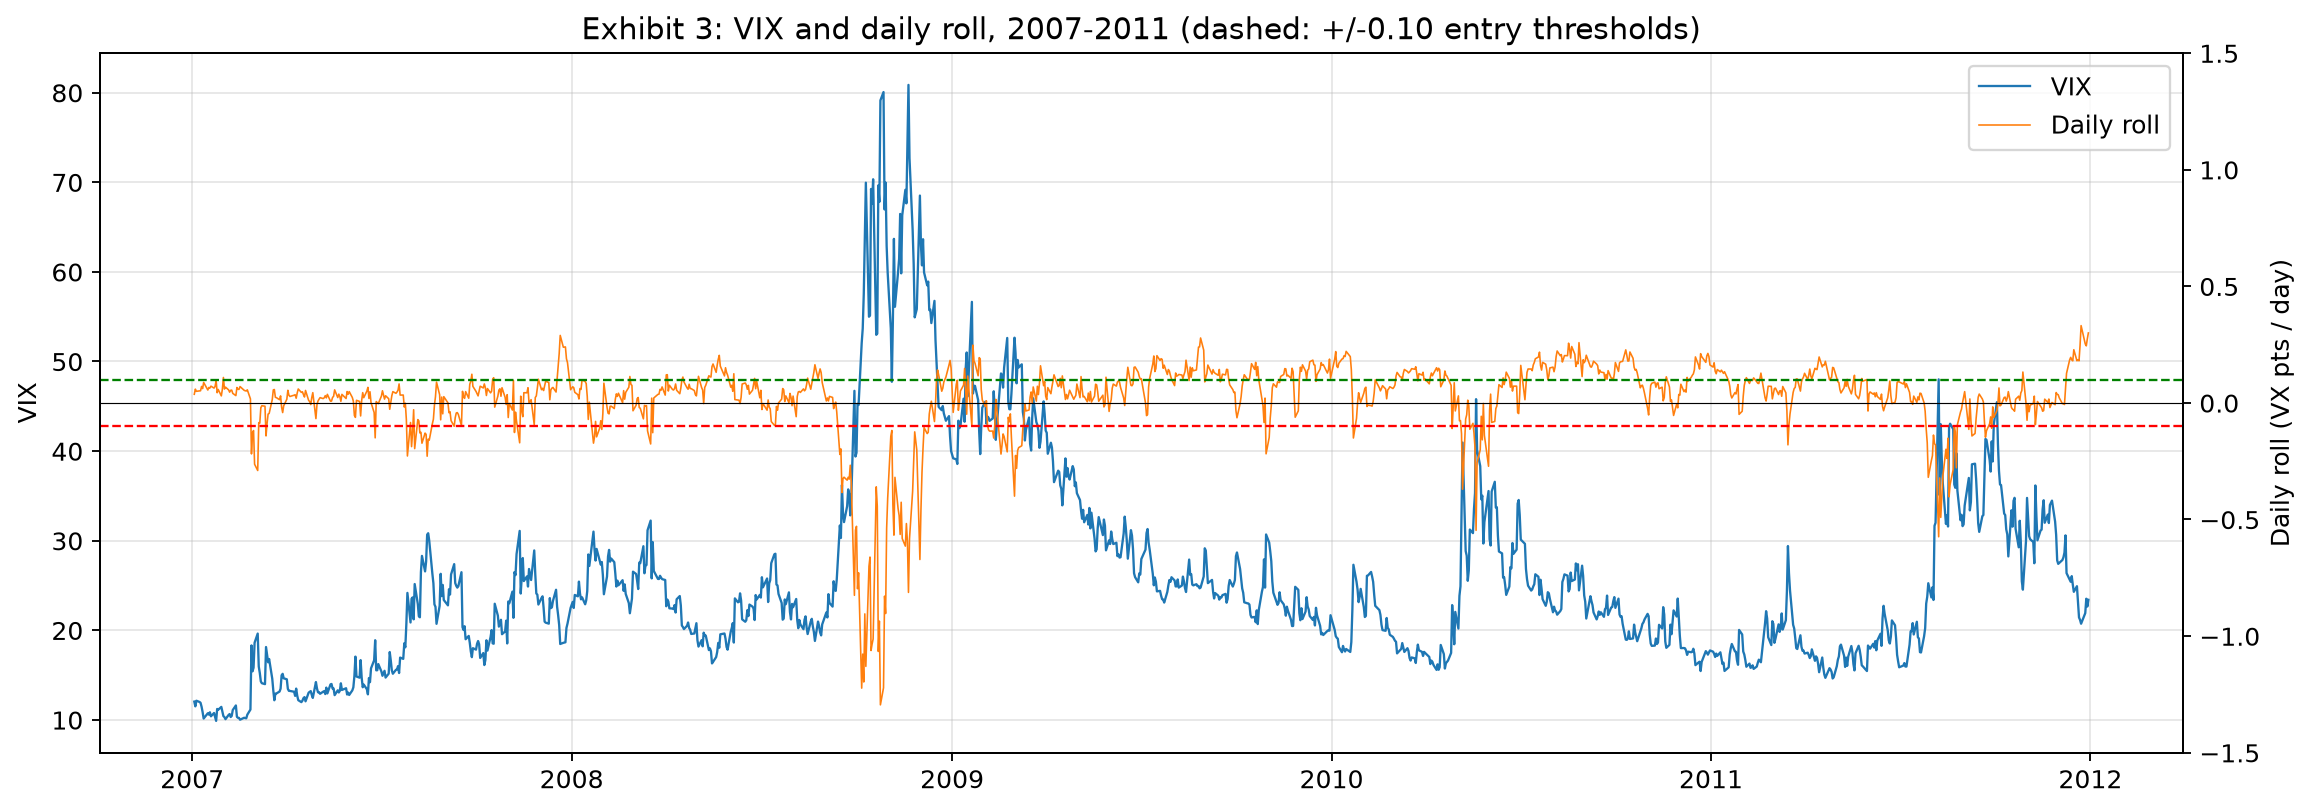

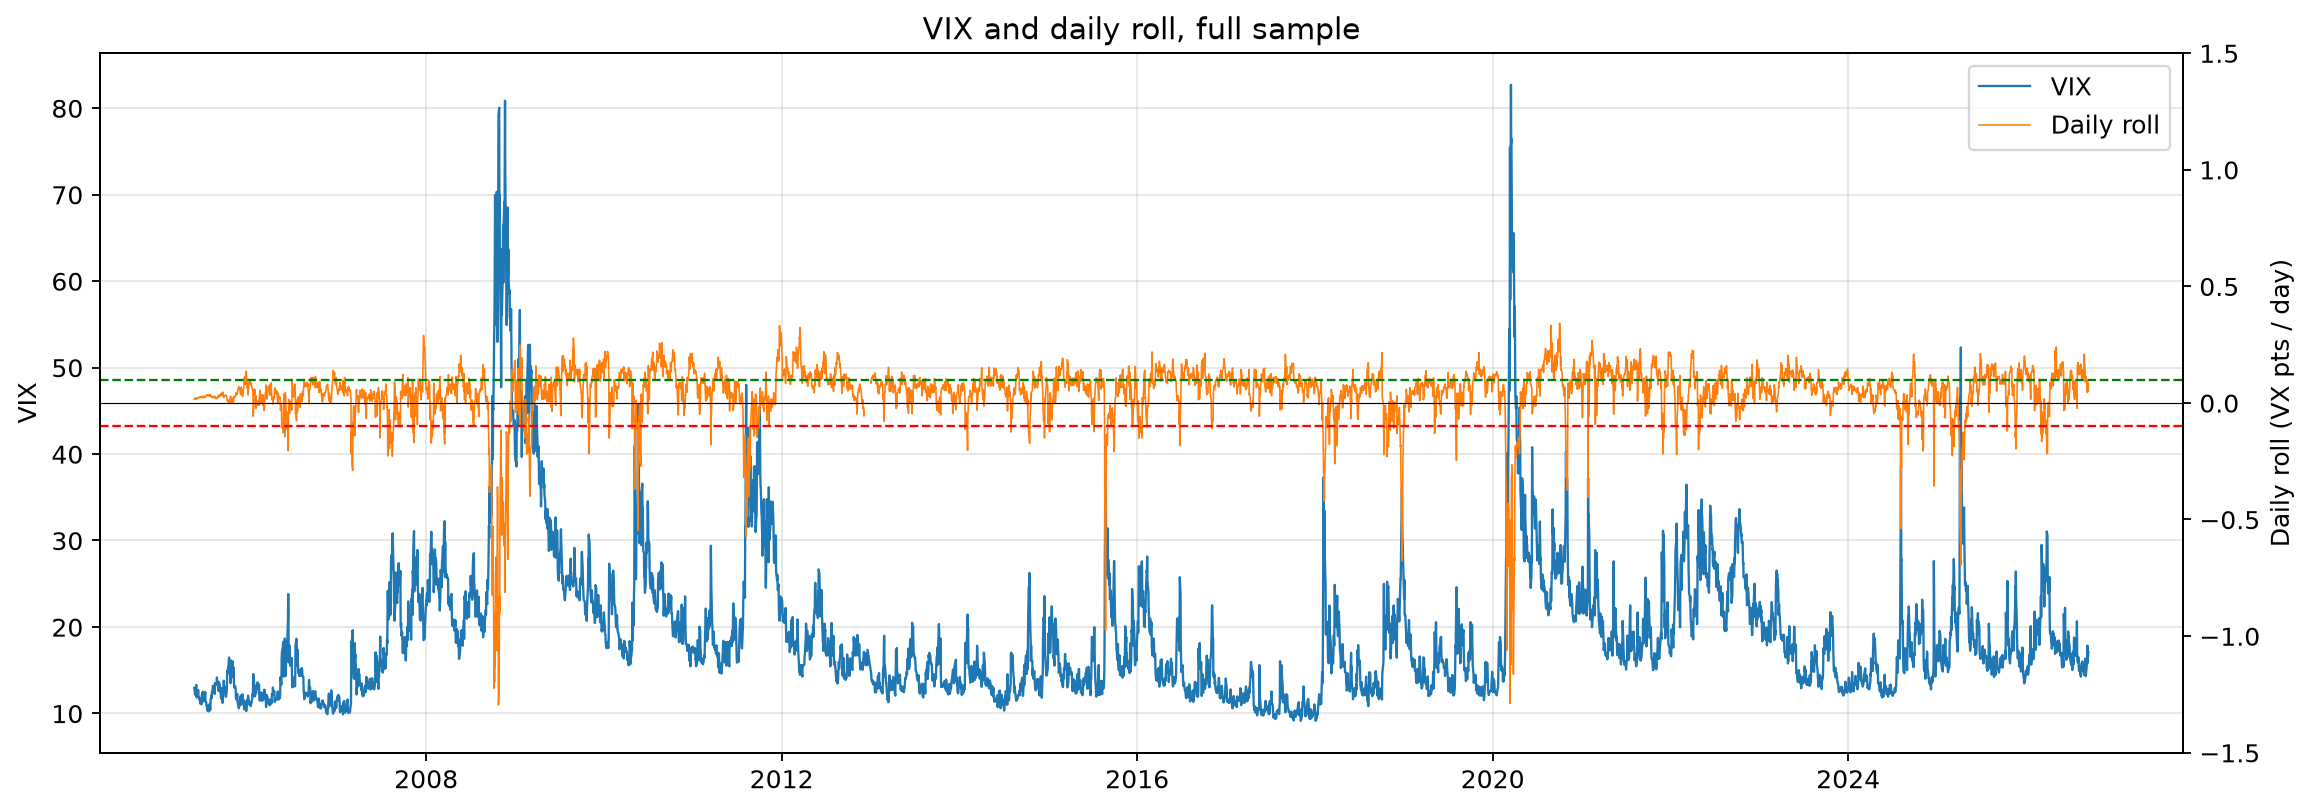

2007-2011  roll > +0.10:  28.0% | roll < -0.10:  12.0% | median 0.050
Full       roll > +0.10:  29.3% | roll < -0.10:   6.4% | median 0.065


In [16]:
def plot_vix_roll(p, title):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(p.index, p.vix, color='tab:blue', lw=1, label='VIX')
    ax.set_ylabel('VIX')
    ax2 = ax.twinx()
    ax2.plot(p.index, p.roll, color='tab:orange', lw=0.7, label='Daily roll')
    for y, c in [(PARAMS['entry_short'], 'green'), (-PARAMS['entry_long'], 'red')]:
        ax2.axhline(y, color=c, ls='--', lw=1)
    ax2.axhline(0, color='k', lw=0.5)
    ax2.set_ylim(-1.5, 1.5); ax2.set_ylabel('Daily roll (VX pts / day)'); ax2.grid(False)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper right'); ax.set_title(title)
    plt.tight_layout(); plt.show()

plot_vix_roll(panel.loc[PAPER_START:PAPER_END], 'Exhibit 3: VIX and daily roll, 2007-2011 (dashed: +/-0.10 entry thresholds)')
plot_vix_roll(panel, 'VIX and daily roll, full sample')

r_ = panel['roll'].dropna()
for lab, s in [('2007-2011', r_.loc[PAPER_START:PAPER_END]), ('Full', r_)]:
    print(f'{lab:10s} roll > +0.10: {(s > .10).mean():6.1%} | roll < -0.10: {(s < -.10).mean():6.1%} | '
          f'median {s.median():.3f}')

## 8. Replication: Exhibit 4 — does the basis forecast VIX or VX?

Observations are taken on the last trading day of each month *t*. The contract is the one settling in month *t+1*, about one month out.

* Eq. (1): VIX<sub>t+1</sub> − VIX<sub>t</sub> = α0 + α1·(F<sub>t</sub> − VIX<sub>t</sub>). VIX<sub>t+1</sub> is the next month-end, as written in the paper. A variant measures VIX at the settlement date instead.
* Eq. (2): F<sub>t+1</sub> − F<sub>t</sub> = β0 + β1·(F<sub>t</sub> − VIX<sub>t</sub>), where F<sub>t+1</sub> is the **final settlement value**. That value is the settlement-day row if the file contains it; otherwise the VIX open on the settlement date is used as a proxy for the SOQ.

H0 for "the basis reflects a risk premium": α1 = 0 and β1 < 0 (β1 = −1 means full convergence). OLS standard errors are shown as in the paper, with Newey-West (1 lag) in brackets.

In [17]:
def final_settlement(exp):
    j = expiries.get_loc(exp)
    if exp in dates:
        k = dates.get_loc(exp)
        if not np.isnan(S_df.values[k, j]):
            return S_df.values[k, j], 'file'
    if exp in vix_spot.index:
        return vix_spot.loc[exp, 'vix_open'], 'vix_open'
    return np.nan, None

me = pd.Series(dates, index=dates).groupby([dates.year, dates.month]).last().values
rows_ = []
for k, t in enumerate(me[:-1]):
    t = pd.Timestamp(t)
    nxt_m = (t + pd.offsets.MonthBegin(1))
    cands = [e for e in expiries if e.year == nxt_m.year and e.month == nxt_m.month]
    if not cands:
        continue
    e = cands[0]; j = expiries.get_loc(e); i = dates.get_loc(t)
    F_t = S[i, j]
    if np.isnan(F_t):
        continue
    F_T, src = final_settlement(e)
    t1 = pd.Timestamp(me[k + 1])
    rows_.append(dict(date=t, expiry=e, vix=vixv[i], F=F_t, basis=F_t - vixv[i],
                      dVIX=vix_spot['vix'].get(t1, np.nan) - vixv[i],
                      dVIX_settle=vix_spot['vix'].get(e, np.nan) - vixv[i],
                      dF=F_T - F_t, settle_src=src))
m4 = pd.DataFrame(rows_).set_index('date')
print('final settlement source:', m4.settle_src.value_counts().to_dict())

def reg(y, x):
    d = pd.concat([y, x], axis=1).dropna()
    if len(d) < 5:
        return None
    X = sm.add_constant(d.iloc[:, 1])
    ols = sm.OLS(d.iloc[:, 0], X).fit()
    hac = sm.OLS(d.iloc[:, 0], X).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    return ols, hac

def ex4(m, dep_vix='dVIX'):
    out = {}
    for dep, lab in [(dep_vix, 'dVIX'), ('dF', 'dF')]:
        for cond, cl in [(None, 'all'), ('+', 'contango'), ('-', 'backw.')]:
            mm = m if cond is None else m[m.basis > 0] if cond == '+' else m[m.basis < 0]
            r = reg(mm[dep], mm['basis'])
            if r is None:
                continue
            o, h = r
            out[(lab, cl)] = {'const': f'{o.params.iloc[0]:.3f} ({o.bse.iloc[0]:.3f})',
                              'basis': f'{o.params.iloc[1]:.3f} ({o.bse.iloc[1]:.3f}) [{h.bse.iloc[1]:.3f}]',
                              't(basis)': round(o.tvalues.iloc[1], 2),
                              't(basis=-1)': round((o.params.iloc[1] + 1) / o.bse.iloc[1], 2) if lab == 'dF' else np.nan,
                              'R2adj': round(o.rsquared_adj, 3), 'DW': round(sm.stats.durbin_watson(o.resid), 2),
                              'N': int(o.nobs)}
    return pd.DataFrame(out)

print(f'Exhibit 4 replication ({REG_START} - {PAPER_END}):')
display(ex4(m4.loc[REG_START:PAPER_END]))
print('Paper: dVIX basis coef .231 (.279) | dF basis coef -.791 (.276)*** | contango -1.12** | backw. -1.54*  | N = 71/53/18')
print('\nVariant: dVIX measured to the settlement date (same horizon as dF):')
display(ex4(m4.loc[REG_START:PAPER_END], 'dVIX_settle'))
print('\nFull sample:')
display(ex4(m4))

final settlement source: {'file': 244, 'vix_open': 3}
Exhibit 4 replication (2006-01-01 - 2011-12-31):


dVIX                                                                      dF                                                
                                all                contango                  backw.                     all                contango                  backw.
const                 0.127 (0.683)           0.855 (1.311)          -3.322 (1.620)           0.011 (0.618)          -0.257 (1.114)          -3.919 (1.415)
basis        -0.284 (0.382) [0.684]  -0.047 (1.055) [0.888]  -1.445 (0.655) [0.808]  -1.802 (0.346) [0.707]  -0.563 (0.896) [0.676]  -3.228 (0.572) [0.637]
t(basis)                    -0.7400                 -0.0400                 -2.2100                 -5.2100                 -0.6300                 -5.6500
t(basis=-1)                     NaN                     NaN                     NaN                 -2.3200                  0.4900                 -3.9000
R2adj                       -0.0060                 -0.0230                  0.1340                  0.2690                 -0.0140                  0.5530
DW                           1.8100                  1.6500                  1.8300                  1.8100                  1.4300                  1.7900
N                                72                      46                      26                      72                      46                      26

Paper: dVIX basis coef .231 (.279) | dF basis coef -.791 (.276)*** | contango -1.12** | backw. -1.54*  | N = 71/53/18

Variant: dVIX measured to the settlement date (same horizon as dF):


dVIX                                                                      dF                                                
                                all                contango                  backw.                     all                contango                  backw.
const                 0.270 (0.696)           0.601 (1.242)          -4.344 (1.598)           0.011 (0.618)          -0.257 (1.114)          -3.919 (1.415)
basis        -1.206 (0.389) [0.869]  -0.321 (0.999) [0.662]  -2.820 (0.646) [0.847]  -1.802 (0.346) [0.707]  -0.563 (0.896) [0.676]  -3.228 (0.572) [0.637]
t(basis)                    -3.1000                 -0.3200                 -4.3700                 -5.2100                 -0.6300                 -5.6500
t(basis=-1)                     NaN                     NaN                     NaN                 -2.3200                  0.4900                 -3.9000
R2adj                        0.1080                 -0.0200                  0.4200                  0.2690                 -0.0140                  0.5530
DW                           1.7800                  1.6500                  1.7400                  1.8100                  1.4300                  1.7900
N                                72                      46                      26                      72                      46                      26


Full sample:


dVIX                                                                     dF                                                
                               all               contango                  backw.                     all                contango                  backw.
const               -0.215 (0.346)         -0.483 (0.582)          -3.103 (1.002)           0.018 (0.311)          -0.320 (0.472)          -3.735 (0.875)
basis        0.469 (0.191) [0.507]  1.164 (0.407) [0.488]  -0.556 (0.394) [0.541]  -1.292 (0.172) [0.551]  -0.393 (0.331) [0.294]  -2.623 (0.344) [0.522]
t(basis)                    2.4600                 2.8600                 -1.4100                 -7.5200                 -1.1900                 -7.6200
t(basis=-1)                    NaN                    NaN                     NaN                 -1.7000                  1.8300                 -4.7200
R2adj                       0.0200                 0.0390                  0.0140                  0.1840                  0.0020                  0.4560
DW                          2.1100                 1.7400                  1.8400                  2.1500                  1.8200                  1.9000
N                              248                    179                      69                     247                     178                      69

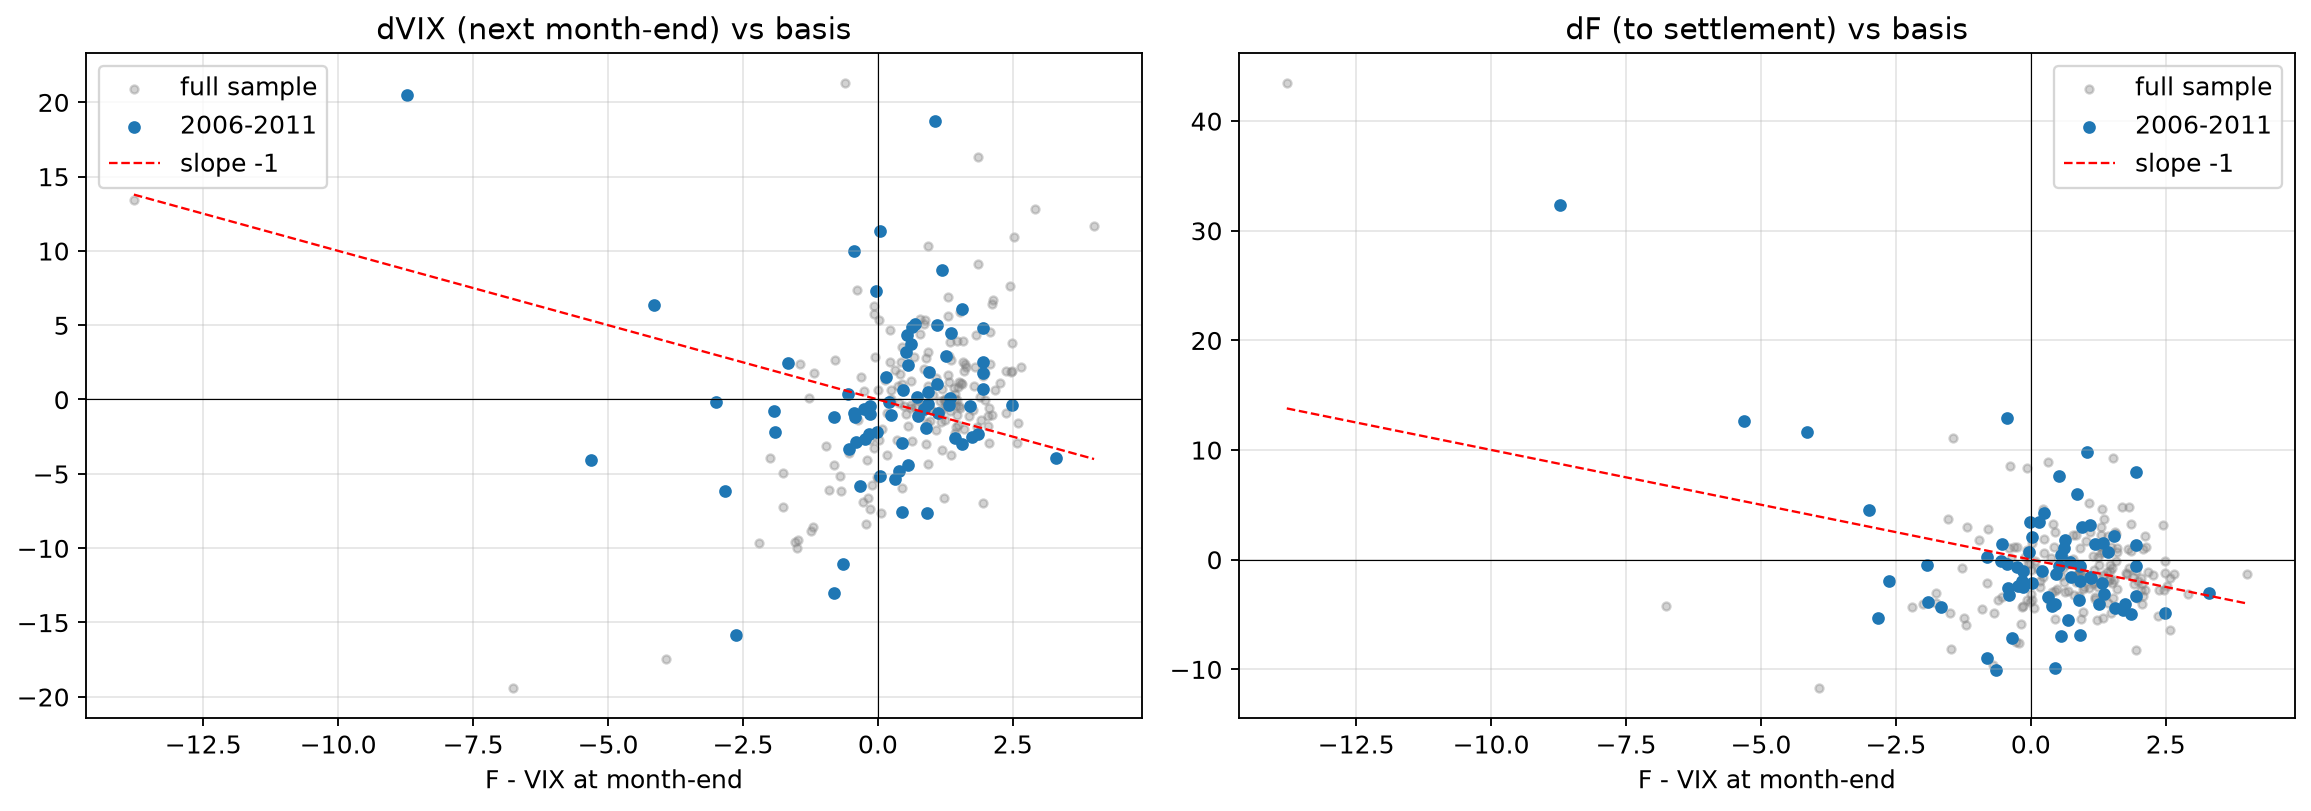

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mm = m4.loc[REG_START:PAPER_END]
for ax, (y, t) in zip(axes, [('dVIX', 'dVIX (next month-end) vs basis'), ('dF', 'dF (to settlement) vs basis')]):
    ax.scatter(m4['basis'], m4[y], s=12, alpha=.35, color='gray', label='full sample')
    ax.scatter(mm['basis'], mm[y], s=20, color='tab:blue', label='2006-2011')
    xs = np.linspace(m4.basis.min(), m4.basis.max(), 50)
    ax.plot(xs, -xs, 'r--', lw=1, label='slope -1')
    ax.axhline(0, color='k', lw=.5); ax.axvline(0, color='k', lw=.5)
    ax.set_xlabel('F - VIX at month-end'); ax.set_title(t); ax.legend()
plt.tight_layout(); plt.show()

## 9. Hedge-ratio model (Eq. 3 and 4)
The full-sample fit is shown for illustration only. The backtest uses the out-of-sample expanding-window coefficients.

Paper (2006–2011): b0 = −0.018, **b1 = −0.717** (0.047), **b2 = 0.011** (0.002), R̄² = 0.45, N = 1511. This implies a response of −0.61 VX points per +1% ES move at 10 days to settlement.

In [19]:
def fit_eq3(start, end):
    d = mkt.reg.loc[start:end]
    d = d[d.use]
    X = sm.add_constant(pd.DataFrame({'SPRET': d.spret, 'SPRETxTTS': d.spret * d.tts_prev}))
    return sm.OLS(d.dF, X).fit(), sm.OLS(d.dF, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

for lab, (a, b) in {'2006-2011': (HEDGE_EST_START, PAPER_END), 'Full sample': (HEDGE_EST_START, None),
                    '2012+': ('2012-01-01', None)}.items():
    o, h = fit_eq3(a, b)
    print(f'{lab:12s} b0={o.params.iloc[0]: .3f} b1={o.params.iloc[1]: .3f} ({o.bse.iloc[1]:.3f}) '
          f'b2={o.params.iloc[2]: .4f} ({o.bse.iloc[2]:.4f}) [HAC {h.bse.iloc[2]:.4f}]  '
          f'R2adj={o.rsquared_adj:.2f}  N={int(o.nobs)}  -> dF per +1% at TTS=10: {o.params.iloc[1] + 10 * o.params.iloc[2]: .3f}')

2006-2011    b0=-0.009 b1=-1.031 (0.034) b2= 0.0190 (0.0016) [HAC 0.0040]  R2adj=0.73  N=1490  -> dF per +1% at TTS=10: -0.841
Full sample  b0=-0.009 b1=-0.920 (0.027) b2= 0.0103 (0.0012) [HAC 0.0037]  R2adj=0.60  N=5143  -> dF per +1% at TTS=10: -0.817
2012+        b0=-0.008 b1=-0.844 (0.038) b2= 0.0039 (0.0018) [HAC 0.0054]  R2adj=0.55  N=3653  -> dF per +1% at TTS=10: -0.805


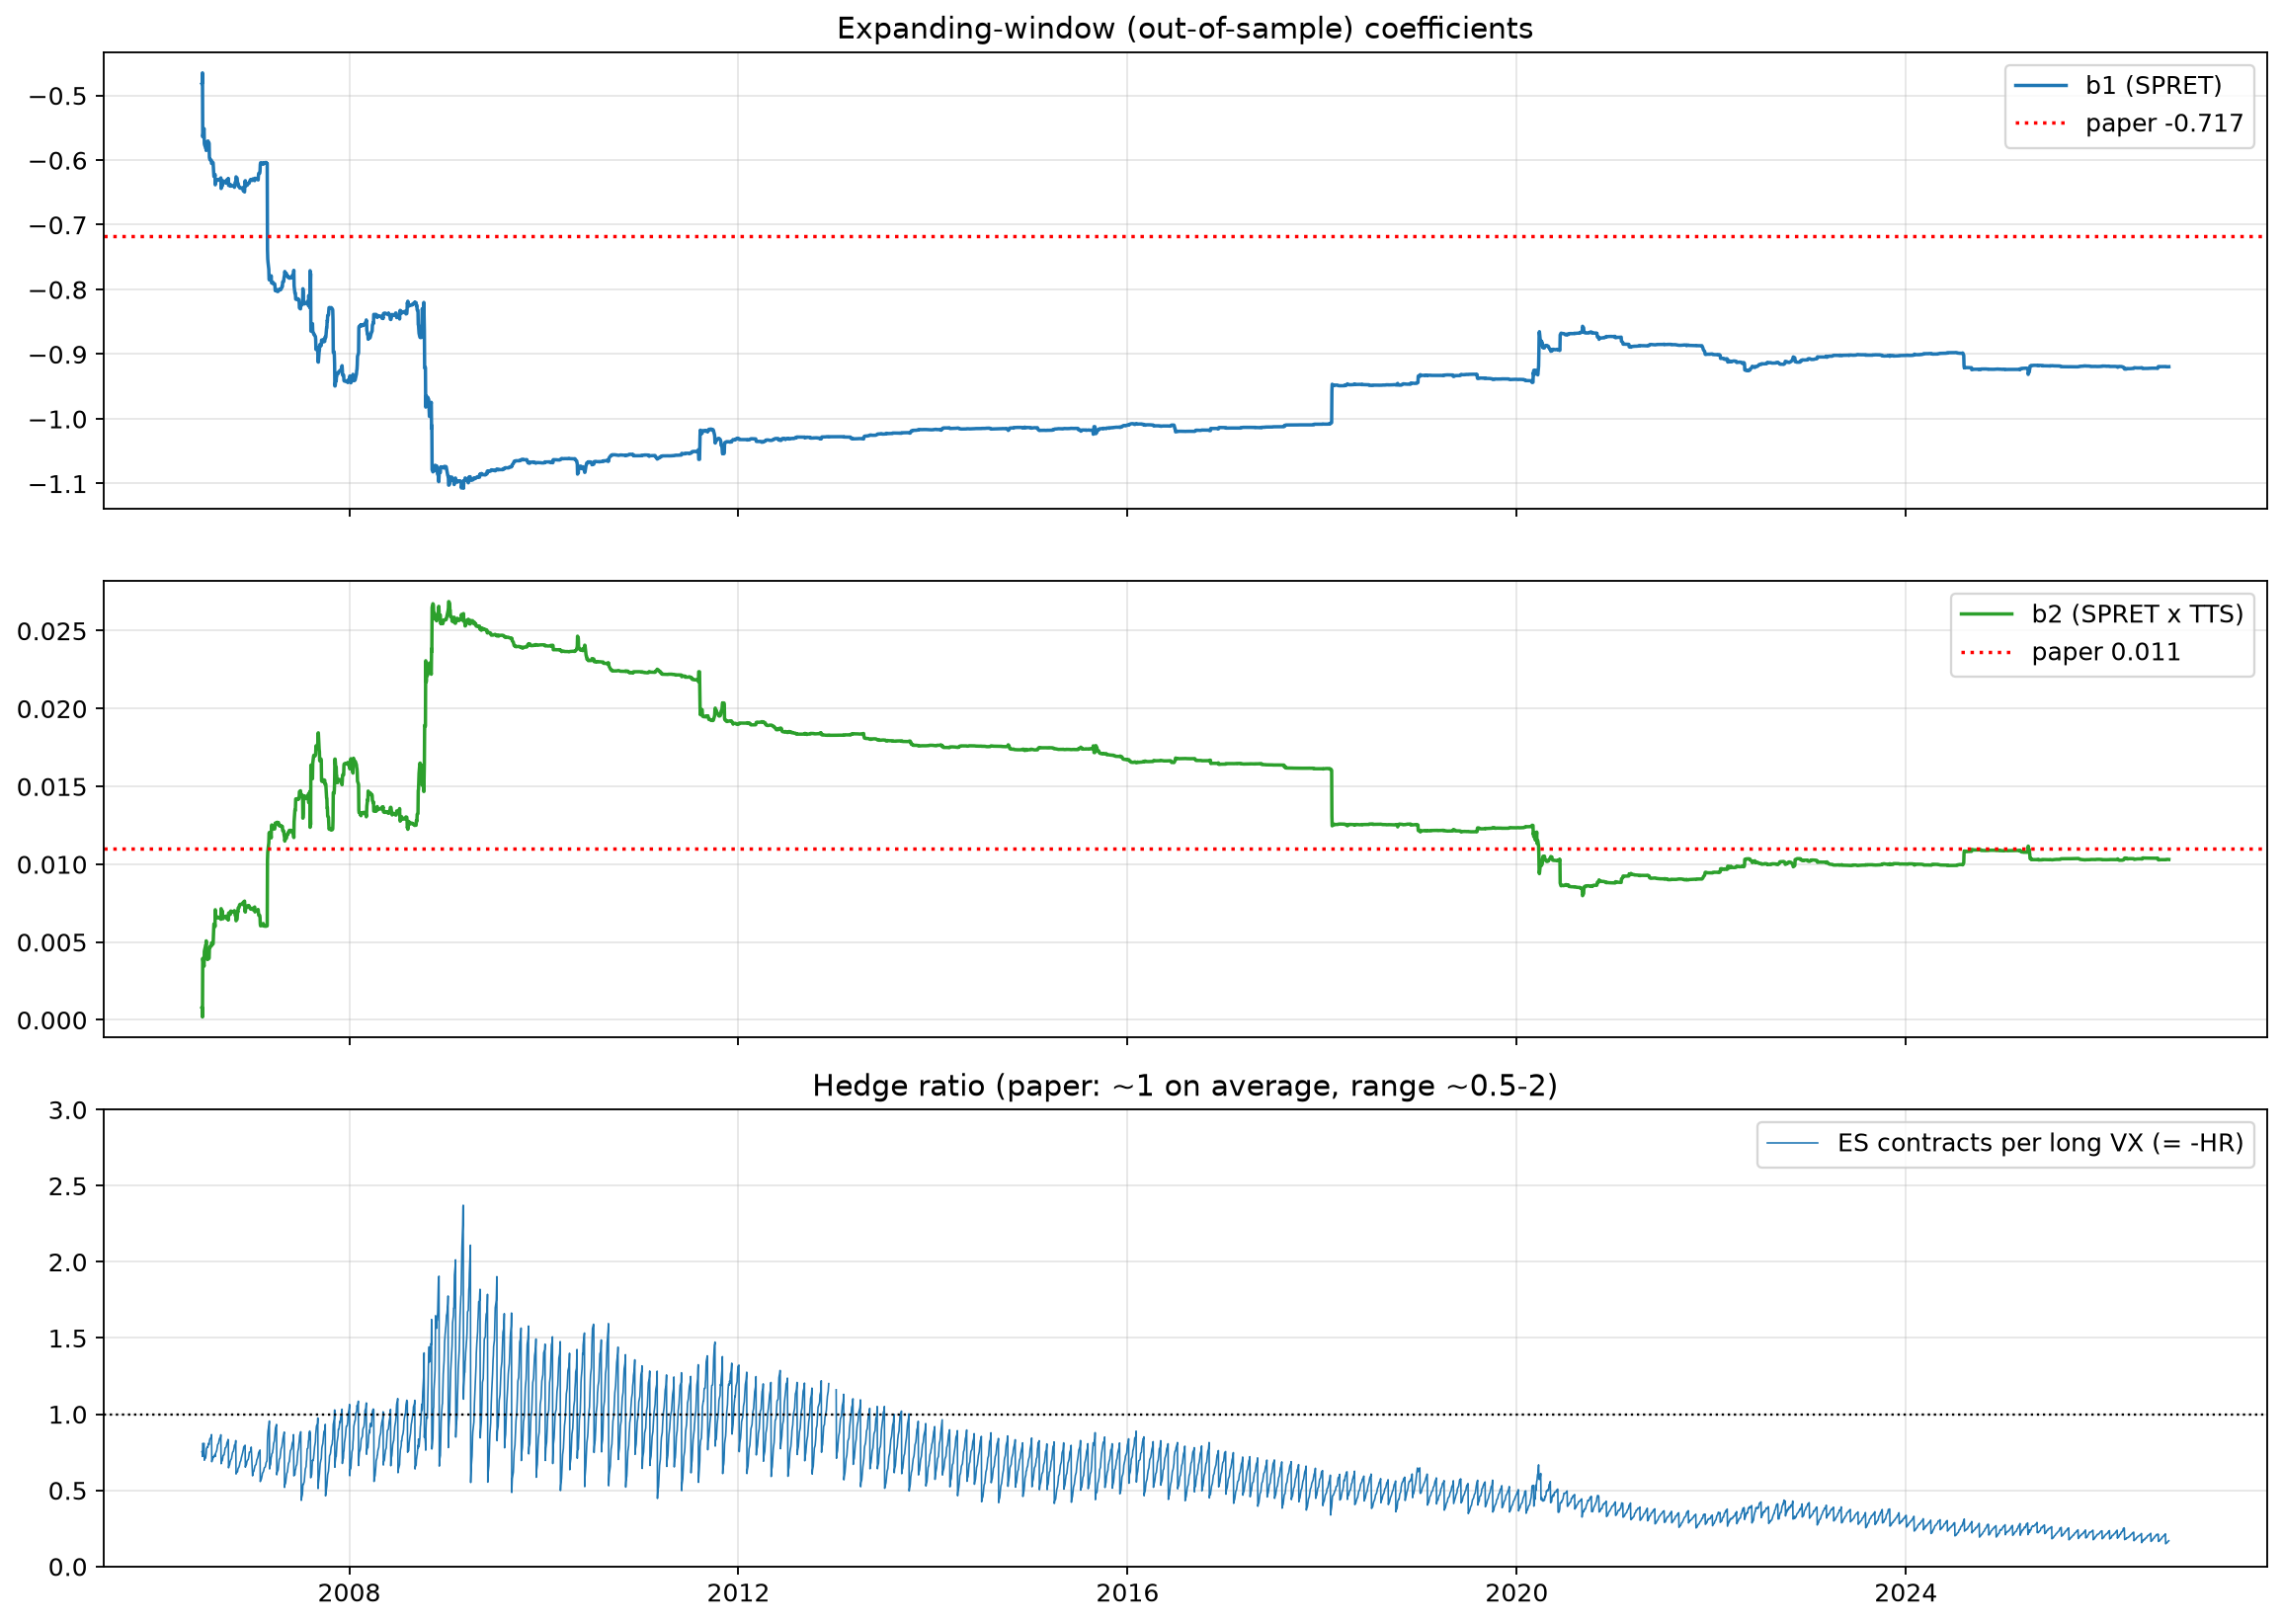

mean |HR| 2007-2011: 1.0 | full sample: 0.63


In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
b = pd.DataFrame(mkt.beta, index=dates, columns=['b0', 'b1', 'b2'])
axes[0].plot(b.index, b.b1, label='b1 (SPRET)'); axes[0].axhline(-0.717, color='r', ls=':', label='paper -0.717')
axes[0].legend(); axes[0].set_title('Expanding-window (out-of-sample) coefficients')
axes[1].plot(b.index, b.b2, color='tab:green', label='b2 (SPRET x TTS)'); axes[1].axhline(0.011, color='r', ls=':', label='paper 0.011')
axes[1].legend()
axes[2].plot(dates, -mkt.hr, lw=.7, label='ES contracts per long VX (= -HR)')
axes[2].axhline(1, color='k', ls=':', lw=1); axes[2].set_ylim(0, 3); axes[2].legend()
axes[2].set_title('Hedge ratio (paper: ~1 on average, range ~0.5-2)')
plt.tight_layout(); plt.show()
print('mean |HR| 2007-2011:', np.nanmean(np.abs(panel.loc[PAPER_START:PAPER_END, 'hr'])).round(2),
      '| full sample:', np.nanmean(np.abs(mkt.hr)).round(2))

## 10. Backtest engine

`run_backtest(market, params, start, end)` works as follows:

* **Signal.** At the close of day *i*, use the traded contract *c* (TTS ≥ `min_tts`) and its daily roll.
* **Entry.** Execute at the close of *e = i + exec_lag* in contract *c*. The hedge ratio uses coefficients estimated through *i−1*, together with TTS<sub>i</sub> and ES<sub>i</sub>.
* **Exit check.** From day *d = max(e, i+1)* onward, recompute the held contract's roll (F<sub>c,d</sub> − VIX<sub>d</sub>)/TTS<sub>c,d</sub>. The trade exits if the roll crosses the exit threshold, if the holding cap is reached, or if the contract is about to settle. The exit executes at *x = d + exec_lag*.
* **P&L.** VX leg = n<sub>vx</sub>·1000·(F<sub>x</sub> − F<sub>e</sub>). ES leg = n<sub>es</sub>·50·(es_pts<sub>x</sub> − es_pts<sub>e</sub>). Costs are charged on both sides. **Roll P&L** = Σ<sub>k=e</sub><sup>x−1</sup> −dir·roll<sub>k</sub>·1000, i.e. the daily roll accrued while the position is held.
* **Daily mark-to-market** is recorded for both legs and reconciled with the trade totals.
* One position at a time. Short and long signals are mutually exclusive.

In [21]:
def vx_cost_side(k):
    base = VX_COST_PER_SIDE
    if VX_COST_VIX_SCALE and np.isfinite(vixv[k]):
        base *= max(1.0, vixv[k] / 20.0)
    return base

def run_backtest(m, p=PARAMS, start=PAPER_START, end=None, vx_cost=None):
    p = {**PARAMS, **p}
    i0 = int(np.searchsorted(dates, pd.Timestamp(start)))
    i1 = N - 1 if end is None else int(np.searchsorted(dates, pd.Timestamp(end), side='right')) - 1
    L, nvx_abs = p['exec_lag'], p['n_vx']
    daily = np.zeros((N, 5))       # vx_pnl, es_pnl, vx_cost, es_cost, position
    trades = []
    last_x = -10**9
    i = i0
    cside = (lambda k: vx_cost) if vx_cost is not None else vx_cost_side
    while i <= i1:
        if (i + L <= last_x) if not p['same_day_reentry'] else (i + L < last_x):
            i += 1; continue
        c = m.sel[i]; r = m.roll[i]
        if c < 0 or not np.isfinite(r) or not np.isfinite(m.hr[i]):
            i += 1; continue
        D = -1 if r > p['entry_short'] else (1 if r < -p['entry_long'] else 0)
        if D == 0:
            i += 1; continue
        e = i + L
        if e >= i1 or np.isnan(S[e, c]) or TTS[e, c] < 2:
            i += 1; continue
        n_vx = D * nvx_abs
        n_es = -D * m.hr[i] * nvx_abs
        # ---- holding loop
        d = max(e, i + 1); reason = None
        while True:
            x = d + L
            if x >= i1:
                x = i1; reason = 'end of sample'; break
            roll_d = (S[d, c] - vixv[d]) / TTS[d, c] if TTS[d, c] >= 1 else np.nan
            if D == -1 and roll_d < p['exit_short']:
                reason = 'roll exit'; break
            if D == 1 and roll_d > -p['exit_long']:
                reason = 'roll exit'; break
            if x - e >= p['max_hold']:
                reason = 'time exit'; break
            if TTS[min(x + 1, N - 1), c] < 1:
                reason = 'settlement'; break
            d += 1
        path = pd.Series(S[e:x + 1, c]).ffill().values   # guard against isolated missing settles
        Fe, Fx = path[0], path[-1]
        vx_g = n_vx * VX_MULT * (Fx - Fe)
        es_g = n_es * ES_MULT * (es_pts[x] - es_pts[e])
        vx_c = nvx_abs * (VX_MULT * (cside(e) + cside(x)) + BROKERAGE_RT)
        es_c = abs(n_es) * (ES_MULT * 2 * ES_COST_PER_SIDE + BROKERAGE_RT)
        ks = np.arange(e, x)
        roll_path = (path[:-1] - vixv[ks]) / TTS[ks, c]
        roll_pnl = float(np.nansum(-D * roll_path) * VX_MULT * nvx_abs)
        # ---- daily MTM
        kk = np.arange(e + 1, x + 1)
        daily[kk, 0] += n_vx * VX_MULT * np.diff(path)
        daily[kk, 1] += n_es * ES_MULT * np.diff(es_pts[e:x + 1])
        daily[e, 2] += nvx_abs * (VX_MULT * cside(e) + BROKERAGE_RT / 2); daily[x, 2] += nvx_abs * (VX_MULT * cside(x) + BROKERAGE_RT / 2)
        daily[e, 3] += es_c / 2; daily[x, 3] += es_c / 2
        daily[e:x, 4] = D
        trades.append(dict(signal_date=dates[i], entry=dates[e], exit=dates[x], side='Short' if D < 0 else 'Long',
                           dir=D, contract=expiries[c].date(), tts_entry=int(TTS[e, c]), vix_entry=vixv[e],
                           F_entry=Fe, F_exit=Fx, basis_entry=Fe - vixv[e], roll_entry=r,
                           hr=m.hr[i], n_es=n_es, es_entry=esv[e], duration=x - e, reason=reason,
                           vx_gross=vx_g, es_gross=es_g, vx_cost=vx_c, es_cost=es_c,
                           unhedged=vx_g - vx_c, hedge=es_g - es_c, hedged=vx_g + es_g - vx_c - es_c,
                           roll_pnl=roll_pnl))
        last_x = x
        i = d if p['same_day_reentry'] else d + 1
    tr = pd.DataFrame(trades)
    dl = pd.DataFrame(daily[i0:i1 + 1], index=dates[i0:i1 + 1], columns=['vx', 'es', 'vx_cost', 'es_cost', 'pos'])
    dl['unhedged'] = dl.vx - dl.vx_cost
    dl['hedged'] = dl.unhedged + dl.es - dl.es_cost
    if len(tr):
        assert np.isclose(dl.hedged.sum(), tr.hedged.sum(), atol=1e-6), 'daily MTM does not reconcile with trades'
    return tr, dl

tr_paper, dl_paper = run_backtest(mkt, PARAMS, PAPER_START, PAPER_END)
print(f'{len(tr_paper)} trades in {PAPER_START} - {PAPER_END}: {tr_paper.side.value_counts().to_dict()}')
print('exit reasons:', tr_paper.reason.value_counts().to_dict())
print(f'avg round-trip cost per trade: ${(tr_paper.vx_cost + tr_paper.es_cost).mean():,.0f} (paper ~$140)')
display(tr_paper.head(10))

98 trades in 2007-01-01 - 2011-12-31: {'Short': 65, 'Long': 33}
exit reasons: {'roll exit': 56, 'time exit': 41, 'end of sample': 1}
avg round-trip cost per trade: $139 (paper ~$140)


,signal_date,entry,exit,side,dir,contract,tts_entry,vix_entry,F_entry,F_exit,basis_entry,roll_entry,hr,n_es,es_entry,duration,reason,vx_gross,es_gross,vx_cost,es_cost,unhedged,hedge,hedged,roll_pnl
0,2007-01-31,2007-01-31,2007-02-09,Short,-1,2007-02-14,10,10.4200,11.5100,11.2300,1.0900,0.1090,-0.7641,-0.7641,"1,443.0000",7,roll exit,280.0000,-0.0000,123.0000,11.8441,157.0000,-11.8441,145.1559,797.4206
1,2007-02-27,2007-02-27,2007-03-12,Long,1,2007-03-21,16,18.3100,14.8100,13.1400,-3.5000,-0.2188,-0.7291,0.7291,"1,395.2500",9,time exit,"-1,670.0000",209.9475,123.0000,11.3015,"-1,793.0000",198.6459,"-1,594.3541","1,311.1938"
2,2007-03-13,2007-03-13,2007-03-15,Long,1,2007-04-18,25,18.1300,14.5900,15.3300,-3.5400,-0.1416,-0.7024,0.7024,"1,379.7500",2,roll exit,740.0000,412.6823,123.0000,10.8878,617.0000,401.7945,"1,018.7945",229.9333
3,2007-06-26,2007-06-26,2007-06-27,Long,1,2007-07-18,15,18.8900,16.6400,15.6100,-2.2500,-0.1500,-0.8050,0.8050,"1,497.7500",1,roll exit,"-1,030.0000",543.1326,123.0000,12.4777,"-1,153.0000",530.6549,-622.3451,150.0000
4,2007-07-27,2007-07-27,2007-08-02,Long,1,2007-08-22,18,24.1700,20.0700,20.8100,-4.1000,-0.2278,-0.7715,0.7715,"1,458.0000",4,roll exit,740.0000,615.3183,123.0000,11.9589,617.0000,603.3594,"1,220.3594",624.0621
5,2007-08-03,2007-08-03,2007-08-16,Long,1,2007-08-22,13,25.1600,22.6100,30.6100,-2.5500,-0.1962,-0.8767,0.8767,"1,443.0000",9,time exit,"8,000.0000",-37.1723,123.0000,13.5882,"7,877.0000",-50.7604,"7,826.2396","1,534.3472"
6,2007-08-17,2007-08-17,2007-08-22,Long,1,2007-09-19,22,29.9900,26.4700,22.7000,-3.5200,-0.1600,-0.6919,0.6919,"1,450.0000",3,roll exit,"-3,770.0000",648.6882,123.0000,10.7250,"-3,893.0000",637.9632,"-3,255.0368",319.5238
7,2007-09-10,2007-09-10,2007-09-12,Long,1,2007-10-17,27,27.3800,24.6700,23.8800,-2.7100,-0.1004,-0.5869,0.5869,"1,455.2500",2,roll exit,-790.0000,616.2504,123.0000,9.0970,-913.0000,607.1534,-305.8466,163.8319
8,2007-09-27,2007-09-27,2007-10-01,Short,-1,2007-10-17,14,17.0000,18.7200,18.4300,1.7200,0.1229,-0.8614,-0.8614,"1,544.5000",2,roll exit,290.0000,-516.8451,123.0000,13.3518,167.0000,-530.1969,-363.1969,193.6264
9,2007-10-17,2007-10-17,2007-10-19,Short,-1,2007-11-21,25,18.5400,21.0700,22.5400,2.5300,0.1012,-0.6722,-0.6722,"1,552.5000",2,roll exit,"-1,470.0000","1,571.2829",123.0000,10.4192,"-1,593.0000","1,560.8637",-32.1363,209.1167


## 11. Statistics and random-entry bootstrap

* **Semi standard deviation** uses a minimum acceptable return of 0: √mean(min(x,0)²), with gains included as zeros. Sortino = mean / semi-sd.
* **p-value (paper).** Draw *n* entry days with replacement (n = number of actual trades on that side) and open same-direction trades with the same costs and hedge rule. Hold each for ⌊d̄⌋ and ⌈d̄⌉ days, where d̄ is the mean actual duration, with no exit rule. Repeat 10,000 times. The p-value is the share of bootstrap means above the actual mean, interpolated between the two holding periods (e.g. d̄ = 6.4 → 0.6·p(6) + 0.4·p(7)).

In [22]:
def semi_sd(x):
    x = np.asarray(x, float)
    return np.sqrt(np.mean(np.minimum(x, 0) ** 2)) if len(x) else np.nan

def random_entry_pnl(m, D, h, start, end):
    i0 = int(np.searchsorted(dates, pd.Timestamp(start)))
    i1 = N - 1 if end is None else int(np.searchsorted(dates, pd.Timestamp(end), side='right')) - 1
    ii = np.arange(i0, i1 - h + 1)
    c = m.sel[ii]
    ok = (c >= 0) & np.isfinite(m.hr[ii])
    ii, c = ii[ok], c[ok]
    Fe, Fx = S[ii, c], S[ii + h, c]
    ok = np.isfinite(Fe) & np.isfinite(Fx)
    ii, c, Fe, Fx = ii[ok], c[ok], Fe[ok], Fx[ok]
    n_es = -D * m.hr[ii]
    cs = np.array([vx_cost_side(k) for k in ii]) + np.array([vx_cost_side(k) for k in ii + h])
    vx = D * VX_MULT * (Fx - Fe) - (VX_MULT * cs + BROKERAGE_RT)
    es = n_es * ES_MULT * (es_pts[ii + h] - es_pts[ii]) - np.abs(n_es) * (ES_MULT * 2 * ES_COST_PER_SIDE + BROKERAGE_RT)
    return {'unhedged': vx, 'hedged': vx + es}

def boot_pvalue(m, D, n, dbar, actual, start, end, col, rng, n_boot=N_BOOT):
    lo, hi = int(np.floor(dbar)), int(np.ceil(dbar))
    hs = [(lo, 1.0)] if lo == hi else [(lo, hi - dbar), (hi, dbar - lo)]
    p, means_all = 0.0, {}
    for h, w in hs:
        pool = random_entry_pnl(m, D, max(h, 1), start, end)[col]
        means = pool[rng.integers(0, len(pool), size=(n_boot, n))].mean(1)
        means_all[h] = means
        p += w * (means > actual).mean()
    return p, means_all

def trade_table(tr, m, start, end, rng=None, boot=True):
    rng = rng or np.random.default_rng(SEED)
    out, boots = {}, {}
    for side, D in [('Short', -1), ('Long', 1)]:
        t = tr[tr.side == side]
        if t.empty:
            continue
        dbar = t.duration.mean()
        for col, lab in [('hedged', 'Hedged'), ('unhedged', 'Unhedged'), ('hedge', 'S&P Hedge'), ('roll_pnl', 'Roll')]:
            x = t[col]
            row = {'Mean': x.mean(), 'P-value': np.nan,
                   'Semi Std Dev': semi_sd(x) if lab != 'Roll' else np.nan,
                   '90% fractile': x.quantile(.9), '10% fractile': x.quantile(.1),
                   'Winners/Losers': f'{(x > 0).sum()}/{(x <= 0).sum()}',
                   'Mean Duration': dbar if lab == 'Hedged' else np.nan,
                   'Sortino': x.mean() / semi_sd(x) if lab in ('Hedged', 'Unhedged') else np.nan,
                   'N': len(x), 'Total': x.sum()}
            if boot and lab in ('Hedged', 'Unhedged'):
                row['P-value'], boots[(side, lab)] = boot_pvalue(m, D, len(t), dbar, x.mean(), start, end, col, rng)
            out[(side, lab)] = row
    return pd.DataFrame(out), boots

def fmt_table(t):
    f = t.copy().astype(object)
    for c in f.columns:
        for r in f.index:
            v = t.loc[r, c]
            if isinstance(v, str): continue
            if pd.isna(v): f.loc[r, c] = '--'
            elif r == 'P-value': f.loc[r, c] = f'({v:.3f})'
            elif r in ('Mean Duration', 'Sortino'): f.loc[r, c] = f'{v:.2f}'
            elif r == 'N': f.loc[r, c] = f'{int(v)}'
            else: f.loc[r, c] = f'{v:,.0f}'
    return f

## 12. Replication: Exhibit 5 — trade P&L, January 2007 to December 2011

In [23]:
ex5, boots5 = trade_table(tr_paper, mkt, PAPER_START, PAPER_END)
display(fmt_table(ex5))

cmp = []
for side in ['Short', 'Long']:
    for lab in ['Hedged', 'Unhedged', 'S&P Hedge', 'Roll']:
        if (side, lab) not in ex5: continue
        pp = PAPER_EX5[side][lab]; me_ = ex5[(side, lab)]
        cmp.append({'side': side, 'leg': lab, 'mean (paper)': pp.get('mean'), 'mean (ours)': round(me_['Mean']),
                    'p (paper)': pp.get('p'), 'p (ours)': None if pd.isna(me_['P-value']) else round(me_['P-value'], 3),
                    'Sortino (paper)': pp.get('sortino'), 'Sortino (ours)': None if pd.isna(me_['Sortino']) else round(me_['Sortino'], 2),
                    'W/L (paper)': pp.get('wl'), 'W/L (ours)': me_['Winners/Losers'],
                    'dur (paper)': pp.get('dur'), 'dur (ours)': None if pd.isna(me_['Mean Duration']) else round(me_['Mean Duration'], 1)})
print('Side by side with the paper:')
display(pd.DataFrame(cmp).set_index(['side', 'leg']))

Short                                Long                           
                 Hedged Unhedged S&P Hedge    Roll   Hedged Unhedged S&P Hedge    Roll
Mean                739      790       -51     898    1,543    1,457        86   1,632
P-value         (0.001)  (0.018)        --      --  (0.000)  (0.005)        --      --
Semi Std Dev        711    1,287     1,150      --      897    1,787     2,649      --
90% fractile      2,583    4,187     1,735   1,649    7,580    8,837     2,411   4,775
10% fractile     -1,220   -1,723    -1,725     166   -1,485   -3,463    -4,512     153
Winners/Losers    44/21    40/25     30/35    65/0    18/15    11/22      24/9    33/0
Mean Duration      6.46       --        --      --     5.21       --        --      --
Sortino            1.04     0.61        --      --     1.72     0.82        --      --
N                    65       65        65      65       33       33        33      33
Total            48,039   51,355    -3,316  58,384   50,907   48,071     2,836  53,872

Side by side with the paper:


mean (paper)  mean (ours)  p (paper)  p (ours)  Sortino (paper)  Sortino (ours) W/L (paper) W/L (ours)  dur (paper)  dur (ours)
side  leg                                                                                                                                       
Short Hedged              792          739     0.0030    0.0010           1.2600          1.0400       40/22      44/21       6.4000      6.5000
      Unhedged            861          790     0.0180    0.0180           0.8800          0.6100       38/24      40/25          NaN         NaN
      S&P Hedge           -69          -51        NaN       NaN              NaN             NaN       29/33      30/35          NaN         NaN
      Roll                831          898        NaN       NaN              NaN             NaN        None       65/0          NaN         NaN
Long  Hedged             1018         1543     0.0010    0.0000           1.0300          1.7200       19/21      18/15       4.3000      5.2000
      Unhedged           1406         1457     0.0010    0.0050           0.9700          0.8200       26/24      11/22          NaN         NaN
      S&P Hedge          -387           86        NaN       NaN              NaN             NaN       23/17       24/9          NaN         NaN
      Roll               1333         1632        NaN       NaN              NaN             NaN        None       33/0          NaN         NaN

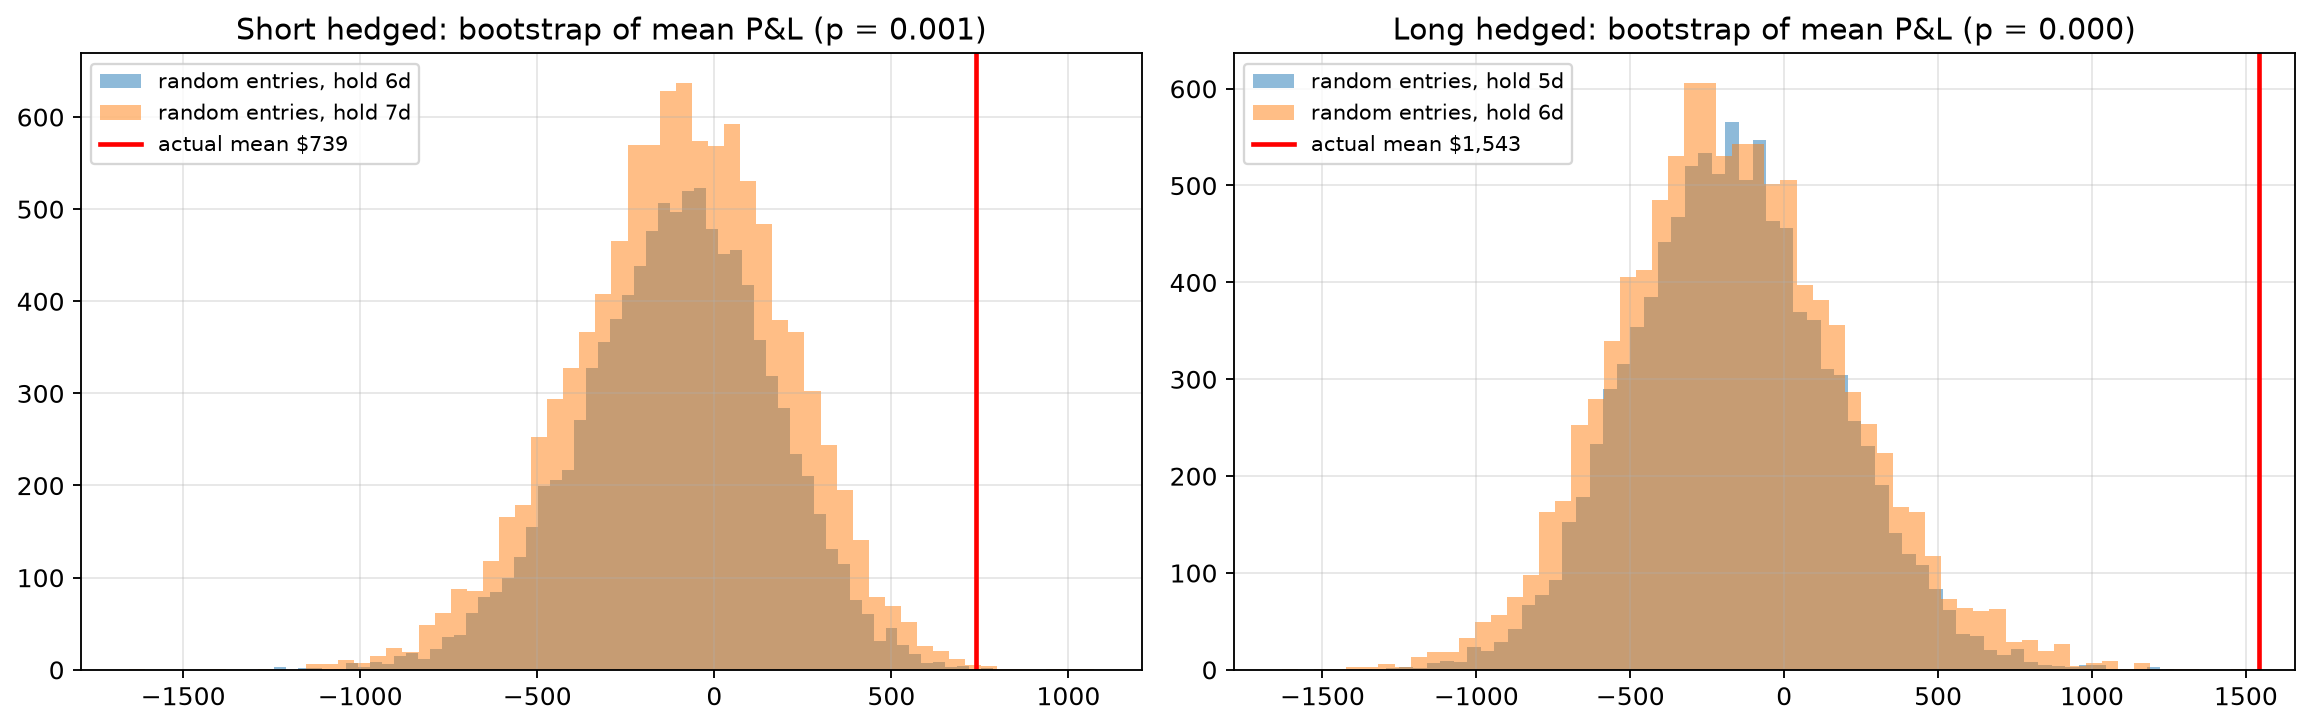

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, side in zip(axes, ['Short', 'Long']):
    k = (side, 'Hedged')
    if k not in boots5: continue
    for h, means in boots5[k].items():
        ax.hist(means, bins=60, alpha=.5, label=f'random entries, hold {h}d')
    ax.axvline(ex5[k]['Mean'], color='r', lw=2, label=f'actual mean ${ex5[k]["Mean"]:,.0f}')
    ax.set_title(f'{side} hedged: bootstrap of mean P&L (p = {ex5[k]["P-value"]:.3f})'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Exhibits 6 and 7 — trade P&L over time and cumulative P&L
The paper plots cumulative P&L by trade. The daily mark-to-market curve is added below; it shows the intra-trade drawdowns that trade-level P&L hides.

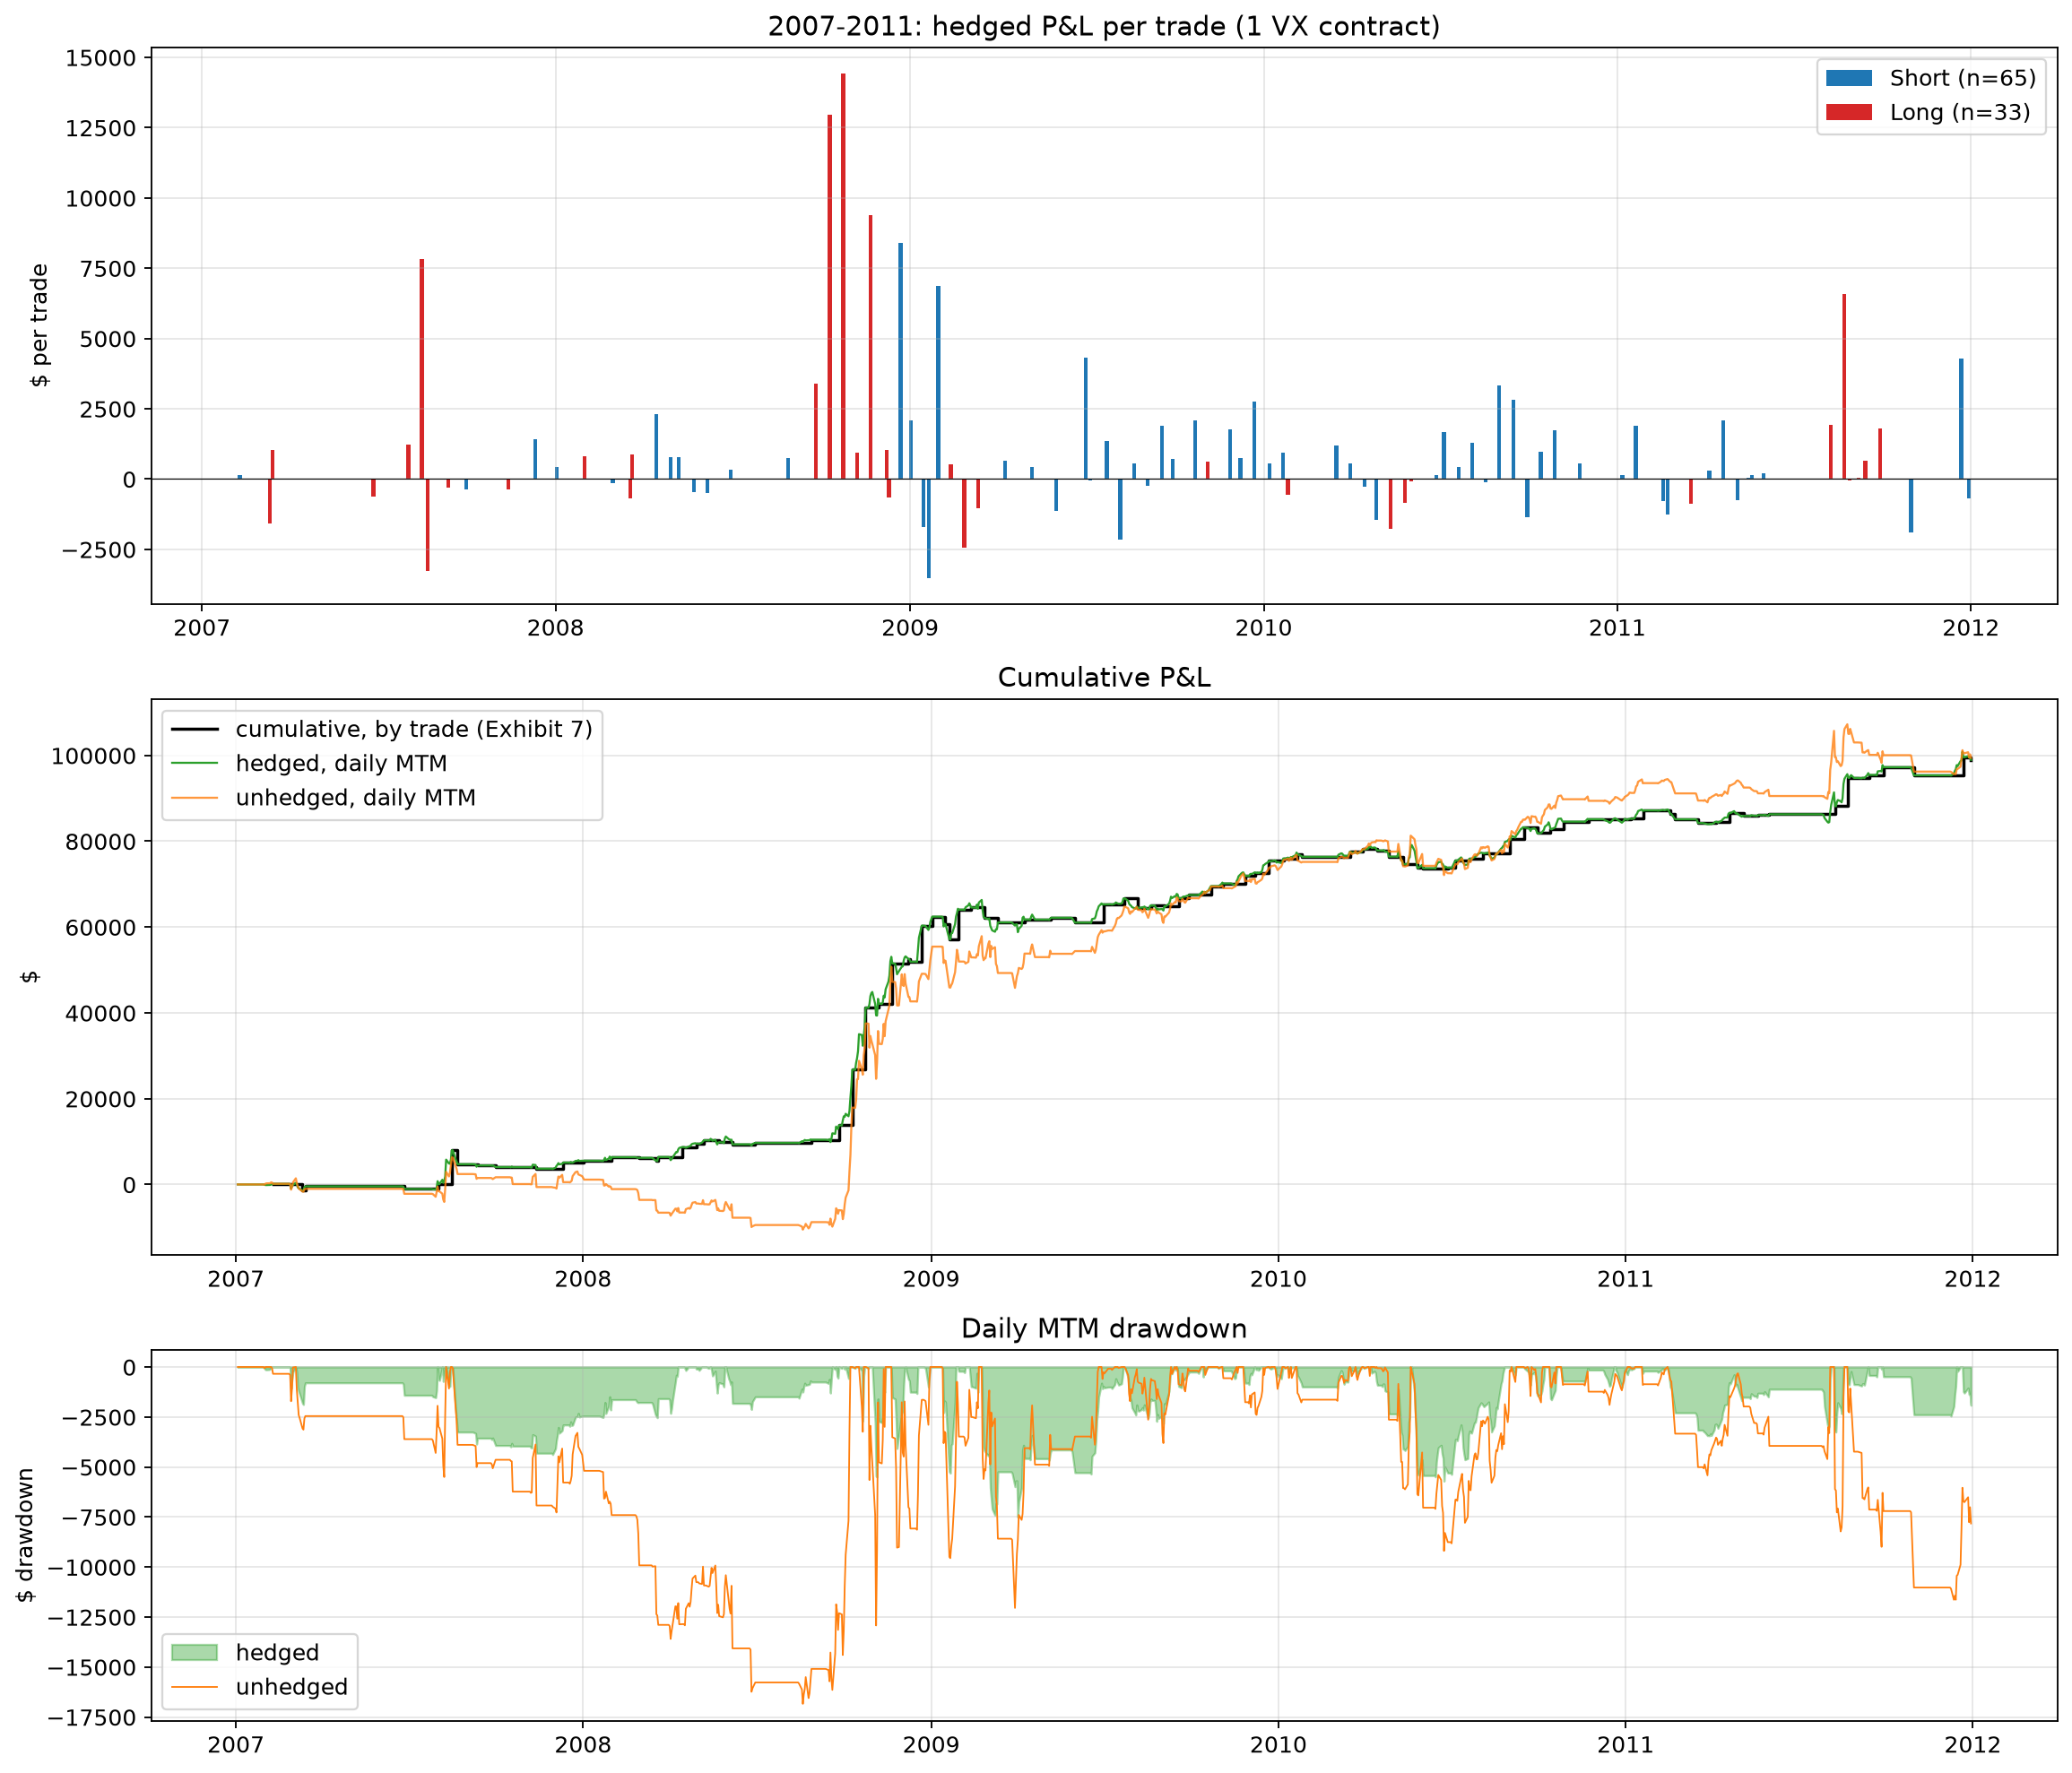

Cumulative hedged P&L 2007-2011: $98,946   (paper: $89,835)
Max daily-MTM drawdown: hedged $-7,513 | unhedged $-16,842


In [25]:
def plot_trades_and_cum(tr, dl, title):
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), height_ratios=[1.2, 1.2, 0.8])
    for side, col in [('Short', 'tab:blue'), ('Long', 'tab:red')]:
        t = tr[tr.side == side]
        axes[0].bar(t.exit, t.hedged, width=4, color=col, label=f'{side} (n={len(t)})')
    axes[0].axhline(0, color='k', lw=.5); axes[0].set_ylabel('$ per trade'); axes[0].legend()
    axes[0].set_title(f'{title}: hedged P&L per trade (1 VX contract)')
    cum_tr = tr.set_index('exit')['hedged'].cumsum()
    axes[1].step(cum_tr.index, cum_tr.values, where='post', color='k', lw=1.5, label='cumulative, by trade (Exhibit 7)')
    axes[1].plot(dl.index, dl.hedged.cumsum(), color='tab:green', lw=1, label='hedged, daily MTM')
    axes[1].plot(dl.index, dl.unhedged.cumsum(), color='tab:orange', lw=1, alpha=.8, label='unhedged, daily MTM')
    axes[1].set_ylabel('$'); axes[1].legend(); axes[1].set_title('Cumulative P&L')
    eq = dl.hedged.cumsum(); dd = eq - eq.cummax()
    axes[2].fill_between(dd.index, dd.values, 0, color='tab:green', alpha=.4, label='hedged')
    eq_u = dl.unhedged.cumsum(); axes[2].plot(eq_u.index, eq_u - eq_u.cummax(), color='tab:orange', lw=.8, label='unhedged')
    axes[2].set_ylabel('$ drawdown'); axes[2].legend(); axes[2].set_title('Daily MTM drawdown')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout(); plt.show()

plot_trades_and_cum(tr_paper, dl_paper, '2007-2011')
print(f'Cumulative hedged P&L 2007-2011: ${tr_paper.hedged.sum():,.0f}   (paper: $89,835)')
print(f'Max daily-MTM drawdown: hedged ${(dl_paper.hedged.cumsum() - dl_paper.hedged.cumsum().cummax()).min():,.0f} | '
      f'unhedged ${(dl_paper.unhedged.cumsum() - dl_paper.unhedged.cumsum().cummax()).min():,.0f}')

### Return on margin (paper, Section III)
The paper states margin requirements of \$6,900 for VX plus \$4,375 for ES. On that basis it reports **55 % p.a.** fully margined and **21 % p.a.** with equity equal to 5× margin, compounded over the 5 years with no reinvestment.

In [26]:
def margin_returns(tr, dl, years=None):
    years = years or (dl.index[-1] - dl.index[0]).days / 365.25
    total = tr.hedged.sum()
    margin = MARGIN_VX + MARGIN_ES          # paper: 1 VX + 1 ES (average hedge size)
    out = {}
    for lab, cap in [('fully margined', margin), (f'{EQUITY_MULTIPLE}x margin', EQUITY_MULTIPLE * margin)]:
        cagr = (1 + total / cap) ** (1 / years) - 1
        eq = cap + dl.hedged.cumsum()
        ret = eq.pct_change().dropna()
        out[lab] = {'capital $': cap, 'total P&L $': total, 'CAGR (no reinvest.)': cagr,
                    'daily Sharpe (ann.)': ret.mean() / ret.std() * np.sqrt(252),
                    'max DD % (MTM)': (eq / eq.cummax() - 1).min()}
    return pd.DataFrame(out)

display(margin_returns(tr_paper, dl_paper).style.format('{:,.3f}'))
print('Paper: 55% (fully margined), 21% (5x margin)')

,fully margined,5x margin
capital $,"11,275.000","56,375.000"
total P&L $,"98,945.809","98,945.809"
CAGR (no reinvest.),0.579,0.225
daily Sharpe (ann.),1.786,2.103
max DD % (MTM),-0.227,-0.068


Paper: 55% (fully margined), 21% (5x margin)


### Exhibit 8 — sub-periods

In [27]:
ex8_rows = []
for lab, (a, b) in {'1/07-6/09': (PAPER_START, PAPER_H1_END), '7/09-12/11': (PAPER_H2_START, PAPER_END)}.items():
    t, _ = run_backtest(mkt, PARAMS, a, b)
    tab, _ = trade_table(t, mkt, a, b)
    print(f'===== {lab} =====')
    display(fmt_table(tab))
    for side in ['Short', 'Long']:
        if (side, 'Hedged') in tab:
            pr = PAPER_EX8[(side, lab)]
            h = tab[(side, 'Hedged')]
            ex8_rows.append({'period': lab, 'side': side, 'mean (paper)': pr[0], 'mean (ours)': round(h['Mean']),
                             'p (paper)': pr[1], 'p (ours)': round(h['P-value'], 3),
                             'Sortino (paper)': pr[2], 'Sortino (ours)': round(h['Sortino'], 2),
                             'n (paper)': pr[3], 'n (ours)': int(h['N']),
                             'hedge leg (ours)': round(tab[(side, 'S&P Hedge')]['Mean'])})
print('Side by side (hedged trades):')
display(pd.DataFrame(ex8_rows).set_index(['period', 'side']))

===== 1/07-6/09 =====


Short                                Long                           
                 Hedged Unhedged S&P Hedge    Roll   Hedged Unhedged S&P Hedge    Roll
Mean                943      625       319     649    2,069    2,107       -38   2,009
P-value         (0.003)  (0.052)        --      --  (0.001)  (0.015)        --      --
Semi Std Dev        867    1,707     1,286      --    1,015    1,956     2,907      --
90% fractile      3,763    5,719     2,229   1,331    9,382   14,457     3,035   5,276
10% fractile     -1,007   -2,351    -1,672     177   -1,594   -3,503    -5,075     150
Winners/Losers     14/9     14/9      14/9    23/0     12/9     8/13      15/6    21/0
Mean Duration      5.17       --        --      --     5.71       --        --      --
Sortino            1.09     0.37        --      --     2.04     1.08        --      --
N                    23       23        23      23       21       21        21      21
Total            21,698   14,371     7,327  14,935   43,457   44,247      -790  42,189

===== 7/09-12/11 =====


Short                                Long                           
                 Hedged Unhedged S&P Hedge    Roll   Hedged Unhedged S&P Hedge    Roll
Mean                633      832      -199   1,034      621      319       302     974
P-value         (0.035)  (0.207)        --      --  (0.021)  (0.146)        --      --
Semi Std Dev        609    1,010     1,067      --      639    1,444     2,122      --
90% fractile      2,075    3,667     1,394   1,659    1,904    4,962     1,965   2,729
10% fractile     -1,228   -1,698    -1,642     173     -868   -2,293    -1,494     222
Winners/Losers    31/11    25/17     17/25    42/0      6/6      3/9       9/3    12/0
Mean Duration      7.17       --        --      --     4.33       --        --      --
Sortino            1.04     0.82        --      --     0.97     0.22        --      --
N                    42       42        42      42       12       12        12      12
Total            26,588   34,934    -8,346  43,438    7,450    3,824     3,626  11,683

Side by side (hedged trades):


mean (paper)  mean (ours)  p (paper)  p (ours)  Sortino (paper)  Sortino (ours)  n (paper)  n (ours)  hedge leg (ours)
period     side                                                                                                                         
1/07-6/09  Short           991          943     0.0090    0.0030           1.9700          1.0900         19        23               319
           Long           1211         2069     0.0140    0.0010           1.0000          2.0400         23        21               -38
7/09-12/11 Short           704          633     0.0740    0.0350           1.0400          1.0400         43        42              -199
           Long            757          621     0.0060    0.0210           1.2900          0.9700         17        12               302

---
## 13. Extension: full sample (2007 → latest)
The same rules and cost assumptions are applied out of sample relative to the paper. The paper's sample ends in 2011, before the VIX ETP boom, Volmageddon, COVID, and the growth of short-dated SPX options.

In [28]:
tr_full, dl_full = run_backtest(mkt, PARAMS, PAPER_START, None)
tab_full, boots_full = trade_table(tr_full, mkt, PAPER_START, None)
print(f'Full sample {dl_full.index[0].date()} - {dl_full.index[-1].date()}: {len(tr_full)} trades')
display(fmt_table(tab_full))

tr_post, dl_post = run_backtest(mkt, PARAMS, '2012-01-01', None)
tab_post, _ = trade_table(tr_post, mkt, '2012-01-01', None)
print('Post-publication sample (2012 ->):')
display(fmt_table(tab_post))

Full sample 2007-01-03 - 2026-09-14: 352 trades


Short                                 Long                            
                 Hedged Unhedged S&P Hedge     Roll   Hedged Unhedged S&P Hedge     Roll
Mean                254      413      -159    1,004      727      433       295    1,391
P-value         (0.006)  (0.098)        --       --  (0.000)  (0.007)        --       --
Semi Std Dev        960    1,325     1,090       --    1,406    2,357     2,248       --
90% fractile      1,815    2,797     1,547    1,621    5,394    7,387     2,603    3,613
10% fractile     -1,208   -2,035    -1,719      230   -1,736   -3,639    -2,836      139
Winners/Losers  153/116  156/113   119/150    269/0    33/50    24/59     59/24     83/0
Mean Duration      7.40       --        --       --     4.78       --        --       --
Sortino            0.26     0.31        --       --     0.52     0.18        --       --
N                   269      269       269      269       83       83        83       83
Total            68,349  111,079   -42,730  270,075   60,375   35,910    24,465  115,429

Post-publication sample (2012 ->):


Short                                 Long                           
                 Hedged Unhedged S&P Hedge     Roll   Hedged Unhedged S&P Hedge    Roll
Mean                 91      279      -188    1,040      189     -243       433   1,231
P-value         (0.185)  (0.456)        --       --  (0.042)  (0.355)        --      --
Semi Std Dev      1,026    1,336     1,066       --    1,658    2,667     1,939      --
90% fractile      1,617    2,522     1,527    1,614    3,890    3,224     2,648   2,972
10% fractile     -1,181   -2,038    -1,683      286   -1,897   -4,667    -2,179     136
Winners/Losers   109/96   116/89    90/115    205/0    15/35    13/37     35/15    50/0
Mean Duration      7.65       --        --       --     4.50       --        --      --
Sortino            0.09     0.21        --       --     0.11    -0.09        --      --
N                   205      205       205      205       50       50        50      50
Total            18,618   57,201   -38,584  213,283    9,468  -12,161    21,629  61,557

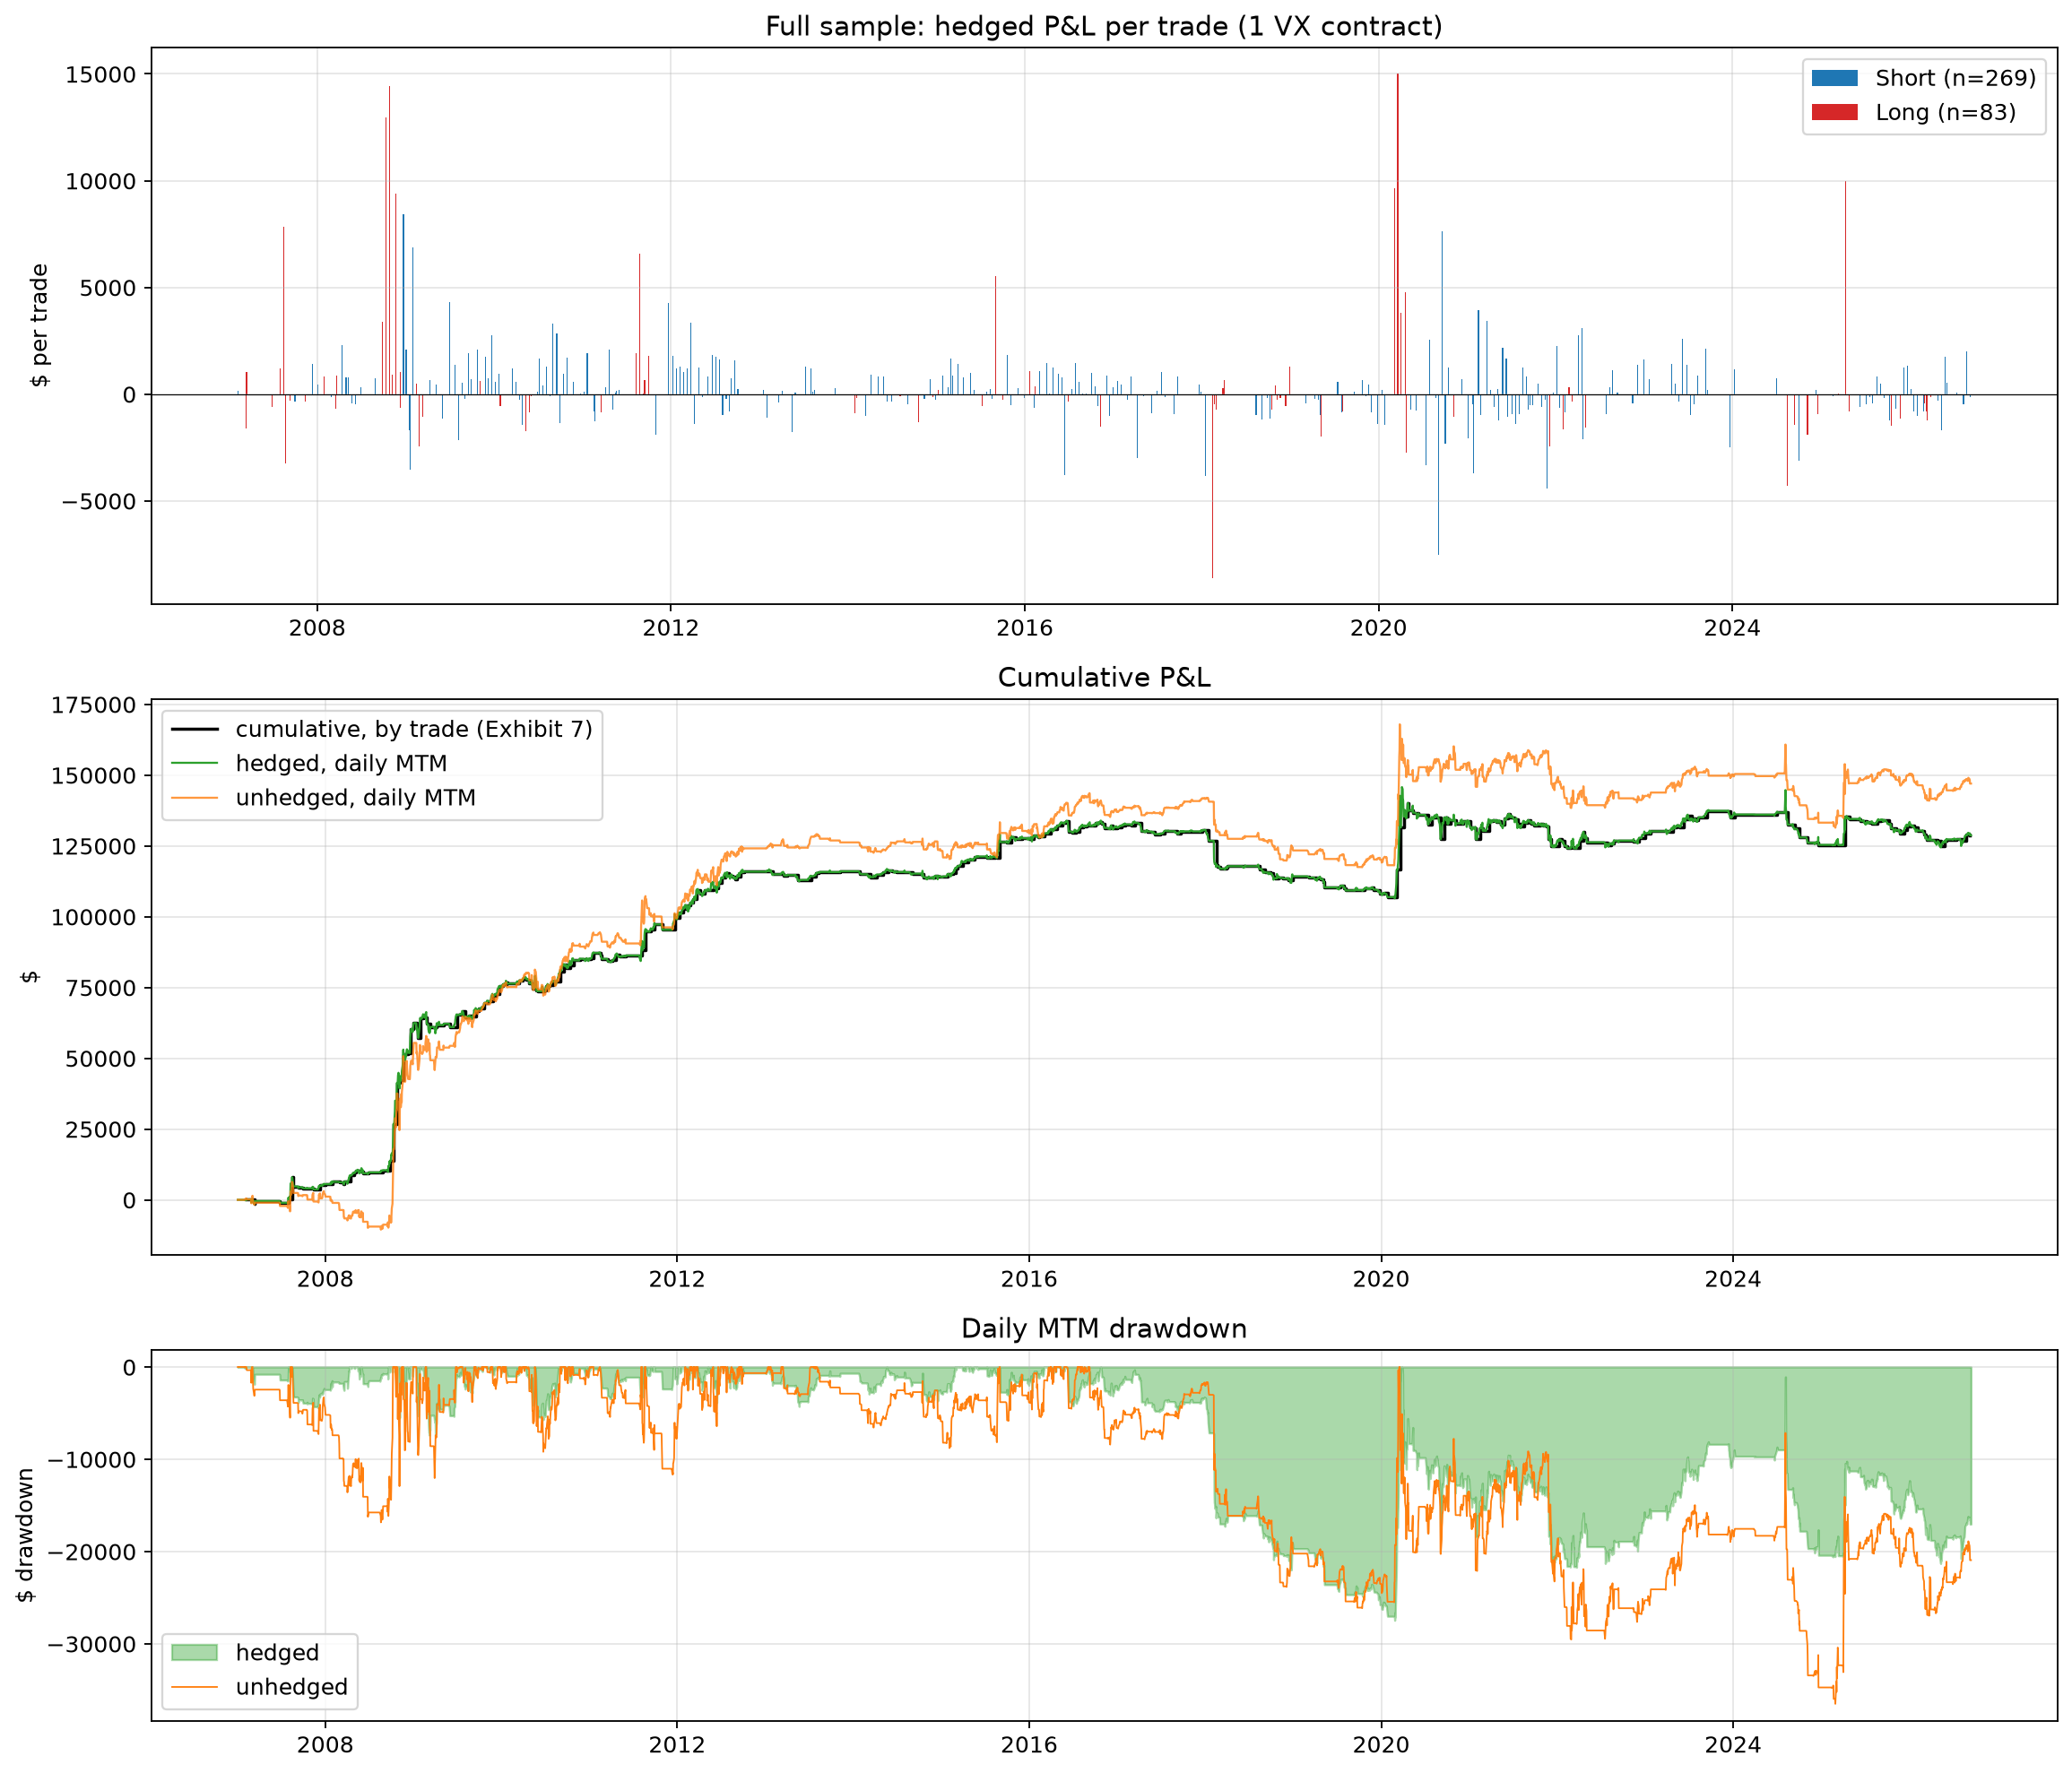

,fully margined,5x margin
capital $,"11,275.000","56,375.000"
total P&L $,"128,724.518","128,724.518"
CAGR (no reinvest.),0.136,0.062
daily Sharpe (ann.),0.928,0.968
max DD % (MTM),-0.227,-0.144


In [29]:
plot_trades_and_cum(tr_full, dl_full, 'Full sample')
display(margin_returns(tr_full, dl_full).style.format('{:,.3f}'))

### Year-by-year

,trades,short,long,hedged $,unhedged $,hedge leg $,roll $,hit rate,worst trade $,best trade $,MTM maxDD $,days in trade
year,,,,,,,,,,,,
2007,12.000000,4.000000,8.000000,5095.732486,544.000000,4551.732486,7017.599345,42%,-3255.036760,7826.239577,-4379.986341,24%
2008,20.000000,10.000000,10.000000,55225.977095,48560.000000,6665.977095,40686.400336,75%,-696.443827,14436.570925,-5503.147039,49%
2009,24.000000,20.000000,4.000000,15105.374737,24738.000000,-9632.625263,21536.123620,62%,-3536.744945,6856.627730,-7513.043468,59%
2010,22.000000,18.000000,4.000000,9716.993462,16394.000000,-6677.006538,24356.494764,64%,-1756.383062,3318.264169,-5708.252914,63%
2011,19.000000,12.000000,7.000000,14484.415484,10313.000000,4171.415484,17556.087942,68%,-1901.069622,6597.131556,-3442.304936,40%
2012,19.000000,19.000000,0.000000,16262.145118,23563.000000,-7300.854882,23897.962047,74%,-1397.777668,3363.974915,-3871.294102,65%
2013,12.000000,12.000000,0.000000,133.969215,2114.000000,-1980.030785,8284.331397,67%,-1761.806417,1297.550180,-4285.030502,29%
2014,15.000000,10.000000,5.000000,-2035.141489,-2995.000000,959.858511,11549.337883,27%,-1308.038386,904.268305,-3725.404761,38%
2015,20.000000,16.000000,4.000000,13539.298673,6265.000000,7274.298673,19578.346646,70%,-555.920066,5546.786762,-3060.309242,53%


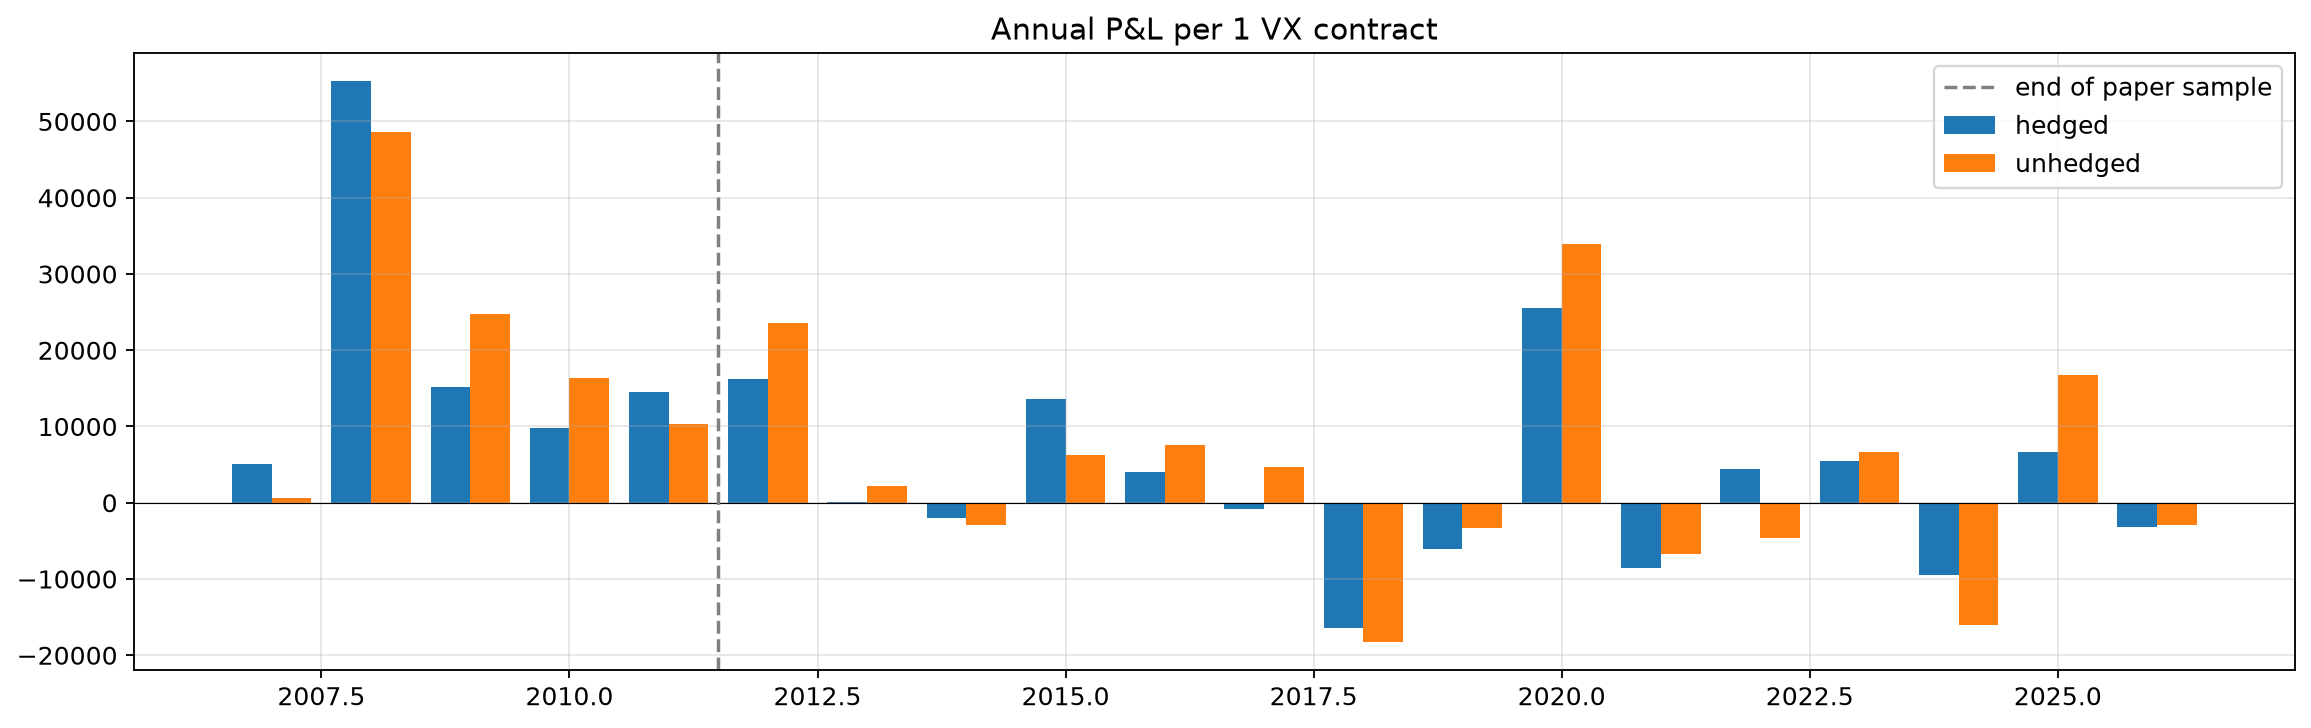

In [30]:
def yearly(tr, dl):
    t = tr.assign(year=tr.exit.dt.year)
    g = t.groupby('year')
    y = pd.DataFrame({
        'trades': g.size(),
        'short': g.apply(lambda x: (x.side == 'Short').sum()),
        'long': g.apply(lambda x: (x.side == 'Long').sum()),
        'hedged $': g.hedged.sum(), 'unhedged $': g.unhedged.sum(), 'hedge leg $': g.hedge.sum(),
        'roll $': g.roll_pnl.sum(),
        'hit rate': g.apply(lambda x: (x.hedged > 0).mean()),
        'worst trade $': g.hedged.min(), 'best trade $': g.hedged.max(),
    })
    dy = dl.groupby(dl.index.year)
    y['MTM maxDD $'] = dy.hedged.apply(lambda s: (s.cumsum() - s.cumsum().cummax()).min())
    y['days in trade'] = dy.pos.apply(lambda s: (s != 0).mean())
    y.loc['Total'] = [y[c].sum() if c.endswith('$') and 'worst' not in c and 'best' not in c and 'MTM' not in c
                      else np.nan for c in y.columns]
    y.loc['Total', ['trades', 'short', 'long']] = [len(tr), (tr.side == 'Short').sum(), (tr.side == 'Long').sum()]
    return y

yr = yearly(tr_full, dl_full)
display(yr.style.format({c: '{:,.0f}' for c in yr.columns if '$' in c or c in ('trades', 'short', 'long')})
          .format({'hit rate': '{:.0%}', 'days in trade': '{:.0%}'})
          .background_gradient(subset=['hedged $'], cmap='RdYlGn'))

fig, ax = plt.subplots(figsize=(14, 4.5))
yy = yr.drop('Total')
w = .4
ax.bar(yy.index - w / 2, yy['hedged $'], w, label='hedged')
ax.bar(yy.index + w / 2, yy['unhedged $'], w, label='unhedged')
ax.axhline(0, color='k', lw=.5); ax.axvline(2011.5, color='gray', ls='--', label='end of paper sample')
ax.set_title('Annual P&L per 1 VX contract'); ax.legend(); plt.tight_layout(); plt.show()

### Short vs. long legs, full sample

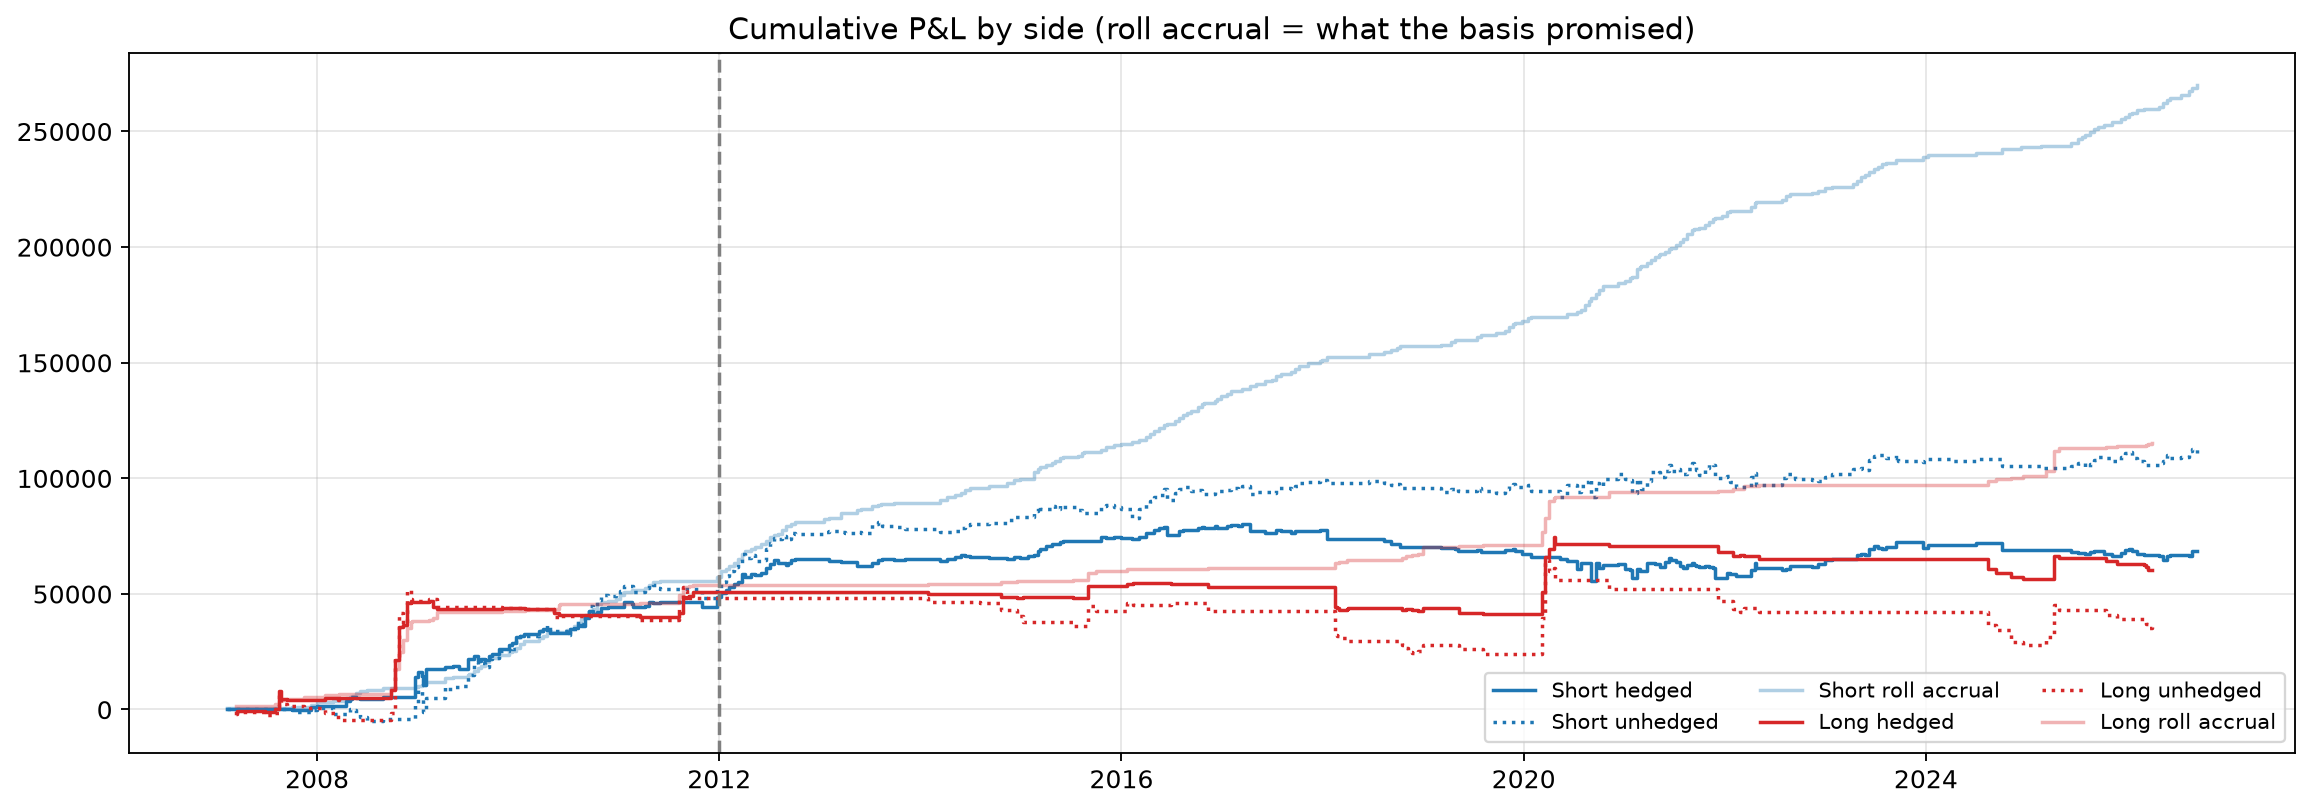

n  mean_hedged  mean_unhedged    hit  mean_roll
side  roll_bucket                                                   
Long  (0.1, 0.15]   46     -53.6009      -310.8152 0.3261   949.8197
      (0.15, 0.2]   13    -216.5935    -1,409.3923 0.2308   523.6234
      (0.2, 0.3]    14     790.0616       343.2786 0.5000 1,234.7731
      (0.3, 0.5]     5   1,487.4995       886.7200 0.6000 2,692.1942
      (0.5, 10.0]    5   9,431.6274    11,858.0000 1.0000 6,836.5689
Short (0.1, 0.15]  222     132.1625       254.7586 0.5360   888.8982
      (0.15, 0.2]   32     713.7921     1,165.0906 0.7188 1,463.8811
      (0.2, 0.3]    14   1,025.8444     1,036.6571 0.7143 1,675.6614
      (0.3, 0.5]     1   1,806.1248     2,727.0000 1.0000 2,436.2701

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
for side, col in [('Short', 'tab:blue'), ('Long', 'tab:red')]:
    t = tr_full[tr_full.side == side].set_index('exit')
    ax.step(t.index, t.hedged.cumsum(), where='post', color=col, label=f'{side} hedged')
    ax.step(t.index, t.unhedged.cumsum(), where='post', color=col, ls=':', label=f'{side} unhedged')
    ax.step(t.index, t.roll_pnl.cumsum(), where='post', color=col, alpha=.35, label=f'{side} roll accrual')
ax.axvline(pd.Timestamp('2012-01-01'), color='gray', ls='--')
ax.set_title('Cumulative P&L by side (roll accrual = what the basis promised)'); ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

by_entry = tr_full.assign(roll_bucket=pd.cut(tr_full.roll_entry.abs(), [0.10, 0.15, 0.20, 0.30, 0.5, 10]))
display(by_entry.groupby(['side', 'roll_bucket'], observed=True)
        .agg(n=('hedged', 'size'), mean_hedged=('hedged', 'mean'), mean_unhedged=('unhedged', 'mean'),
             hit=('hedged', lambda x: (x > 0).mean()), mean_roll=('roll_pnl', 'mean')))

### Stress episodes

,date,VIX,pos on day,+/-3w hedged $,+/-3w unhedged $,worst day hedged $,trades
event,,,,,,,
Lehman,2008-09-15,31.7000,1.0000,"5,625.6655","7,814.0000",-685.4155,"Short(2008-08-15: 738), Long(2008-09-15: 3,393..."
Flash crash,2010-05-06,32.8000,1.0000,"-4,251.5966","-5,280.5000","-2,142.4896","Short(2010-04-01: -275), Short(2010-04-20: -1,..."
US downgrade,2011-08-08,48.0000,1.0000,"8,463.1969","12,481.0000","-3,188.0847","Long(2011-07-27: 1,915), Long(2011-08-10: 6,59..."
Volmageddon,2018-02-05,37.3200,1.0000,"-10,202.8768","-12,007.5000","-6,062.3687","Short(2018-01-02: -3,848), Long(2018-02-05: -8..."
COVID,2020-03-16,82.6900,1.0000,"28,425.5647","36,044.5000","-7,191.8799","Long(2020-02-24: 9,663), Long(2020-03-09: 15,0..."
Yen carry unwind,2024-08-05,38.5700,1.0000,"-4,289.9457","-5,730.4000","-5,630.9907","Long(2024-08-02: -4,290)"
Tariff shock,2025-04-07,46.9800,1.0000,"9,188.0436","11,531.8000","-3,921.2102","Long(2025-03-31: 9,992), Long(2025-04-14: -804)"


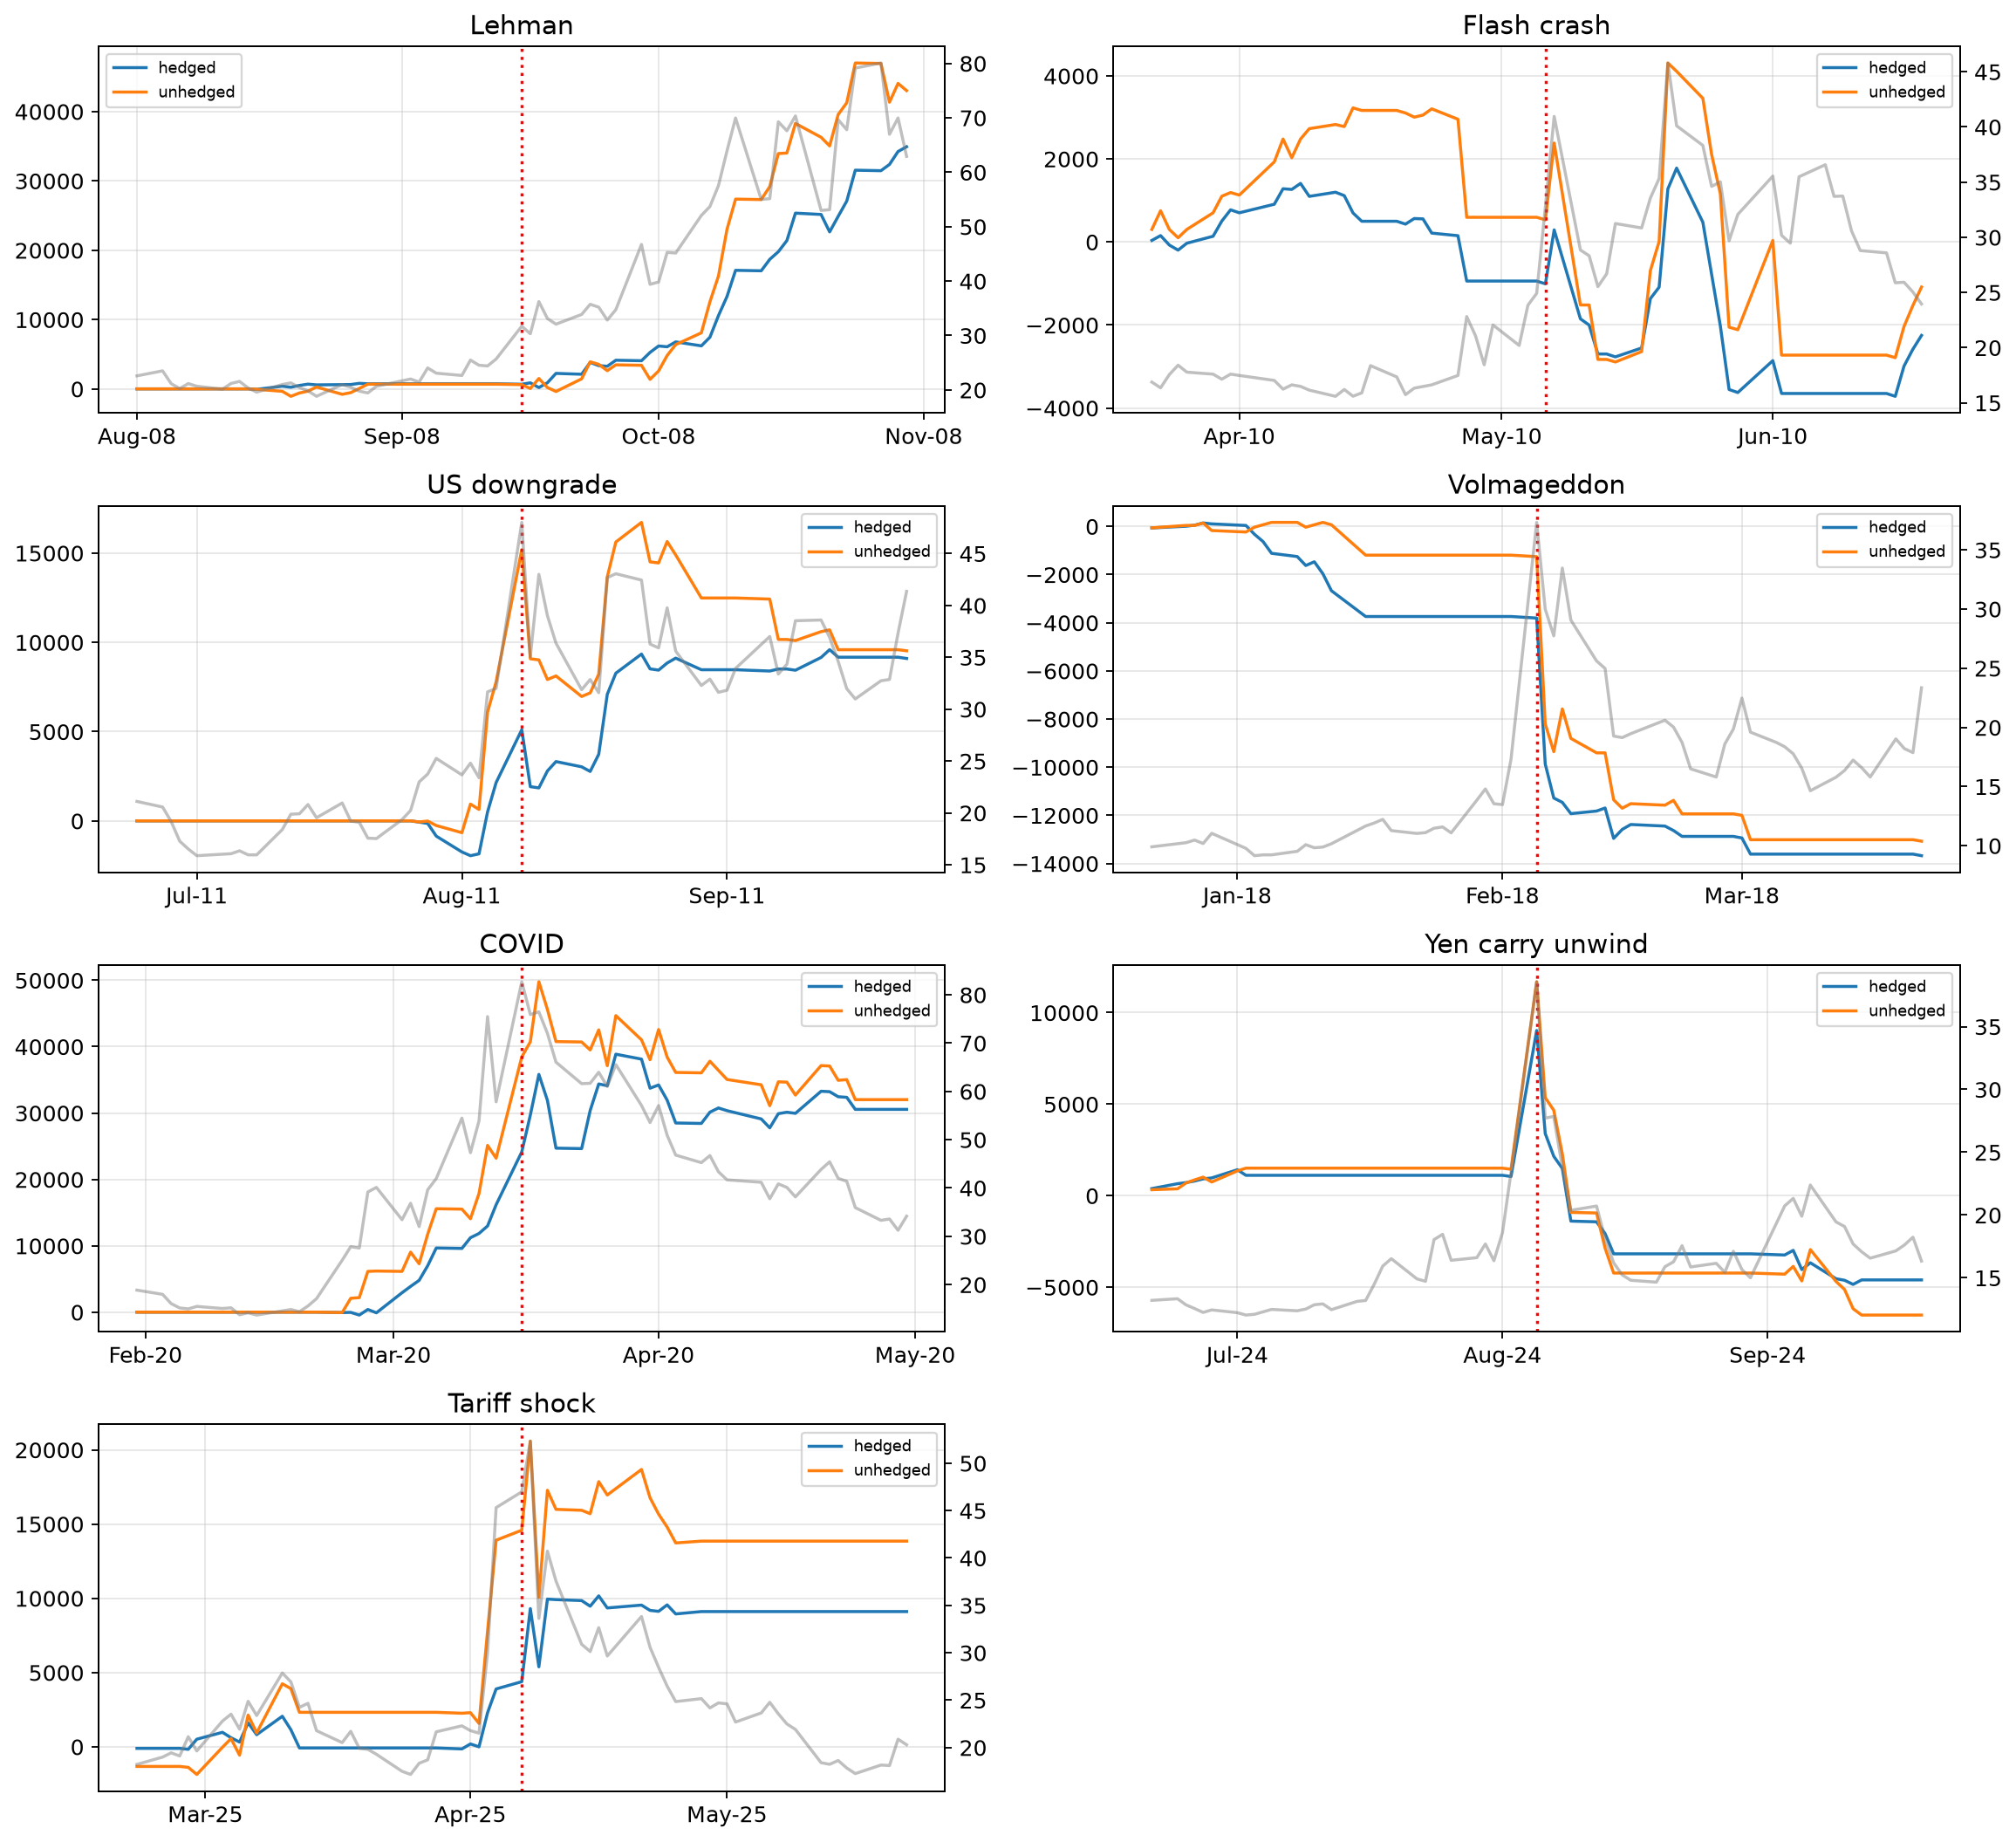

In [32]:
rows_ = []
for name, d in STRESS_EVENTS.items():
    d = pd.Timestamp(d)
    if d < dl_full.index[0] or d > dl_full.index[-1]:
        continue
    win = dl_full.loc[d - pd.Timedelta(days=21): d + pd.Timedelta(days=21)]
    hit = tr_full[(tr_full.entry <= d + pd.Timedelta(days=21)) & (tr_full.exit >= d - pd.Timedelta(days=21))]
    rows_.append({'event': name, 'date': d.date(), 'VIX': panel.vix.asof(d),
                  'pos on day': dl_full.pos.asof(d), '+/-3w hedged $': win.hedged.sum(),
                  '+/-3w unhedged $': win.unhedged.sum(), 'worst day hedged $': win.hedged.min(),
                  'trades': ', '.join(f'{r.side}({r.entry.date()}: {r.hedged:,.0f})' for r in hit.itertuples())})
display(pd.DataFrame(rows_).set_index('event'))

ev = [(n, pd.Timestamp(d)) for n, d in STRESS_EVENTS.items() if dl_full.index[0] <= pd.Timestamp(d) <= dl_full.index[-1]]
if ev:
    fig, axes = plt.subplots(int(np.ceil(len(ev) / 2)), 2, figsize=(14, 3.2 * np.ceil(len(ev) / 2)))
    for ax, (n, d) in zip(np.ravel(axes), ev):
        w = dl_full.loc[d - pd.Timedelta(days=45): d + pd.Timedelta(days=45)]
        ax.plot(w.index, w.hedged.cumsum(), label='hedged'); ax.plot(w.index, w.unhedged.cumsum(), label='unhedged')
        ax2 = ax.twinx(); ax2.plot(w.index, panel.vix.reindex(w.index), color='gray', alpha=.5); ax2.grid(False)
        ax.axvline(d, color='r', ls=':'); ax.set_title(n); ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
    for ax in np.ravel(axes)[len(ev):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

### Largest losses

In [33]:
display(tr_full.nsmallest(10, 'hedged')[['side', 'entry', 'exit', 'duration', 'reason', 'vix_entry', 'roll_entry',
                                          'F_entry', 'F_exit', 'hr', 'unhedged', 'hedge', 'hedged']])

,side,entry,exit,duration,reason,vix_entry,roll_entry,F_entry,F_exit,hr,unhedged,hedge,hedged
203,Long,2018-02-05,2018-02-16,9,time exit,37.3200,-0.3015,27.9750,17.7750,-0.3903,"-10,323.0000","1,683.7918","-8,639.2082"
246,Short,2020-08-26,2020-09-03,6,roll exit,23.2700,0.2004,26.0750,33.8750,-0.4301,"-7,923.0000",396.5529,"-7,526.4471"
277,Short,2021-11-19,2021-11-26,4,roll exit,17.9100,0.1313,20.7994,26.5412,-0.2931,"-5,864.8000","1,442.7331","-4,422.0669"
313,Long,2024-08-02,2024-08-14,8,roll exit,23.3900,-0.1183,21.8527,16.2453,-0.2861,"-5,730.4000","1,440.4543","-4,289.9457"
202,Short,2018-01-02,2018-01-16,9,time exit,9.7700,0.1105,10.8750,11.7750,-0.6291,"-1,023.0000","-2,824.7699","-3,847.7699"
172,Short,2016-06-06,2016-06-13,5,roll exit,13.6500,0.1040,16.8750,21.2250,-0.4699,"-4,473.0000",685.8189,"-3,787.1811"
254,Short,2021-01-25,2021-01-27,2,roll exit,23.1900,0.1727,25.9535,31.5342,-0.3807,"-5,703.7000","1,978.6969","-3,725.0031"
34,Short,2009-01-16,2009-01-20,1,roll exit,46.1100,0.1152,48.5300,54.6600,-1.2876,"-6,253.0000","2,716.2551","-3,536.7449"
242,Short,2020-07-02,2020-07-13,6,roll exit,27.6800,0.1073,29.0750,31.8250,-0.4841,"-2,873.0000",-473.4497,"-3,346.4497"
6,Long,2007-08-17,2007-08-22,3,roll exit,29.9900,-0.1600,26.4700,22.7000,-0.6919,"-3,893.0000",637.9632,"-3,255.0368"


---
## 14. Robustness
Each variant changes a single dimension relative to the paper rules. Every variant is reported for the paper sample and the full sample.

* **Trade-level metrics:** mean hedged P&L, Sortino.
* **Daily-MTM metrics:** annualised Sharpe of daily \$ P&L (scale-free), max drawdown in \$.

Bootstrap p-values are skipped here to keep run time down.

In [34]:
_mkt_cache = {}
def get_mkt(min_tts=10, window=HEDGE_WINDOW, beta=None):
    key = (min_tts, window, None if beta is None else tuple(np.round(beta, 6)))
    if key not in _mkt_cache:
        _mkt_cache[key] = Market(min_tts, window, beta)
    return _mkt_cache[key]

def summarize(tr, dl, col='hedged'):
    if tr.empty:
        return {}
    s = tr[tr.side == 'Short'][col]; l = tr[tr.side == 'Long'][col]
    x = dl[col]; eq = x.cumsum()
    return {'n short': len(s), 'n long': len(l),
            'mean short': s.mean(), 'mean long': l.mean(), 'mean all': tr[col].mean(),
            'Sortino all': tr[col].mean() / semi_sd(tr[col]),
            'total $': tr[col].sum(), 'daily Sharpe': x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan,
            'max DD $': (eq - eq.cummax()).min(), '% days in mkt': (dl.pos != 0).mean()}

def run_variants(variants, periods=None):
    periods = periods or {'2007-2011': (PAPER_START, PAPER_END), 'Full': (PAPER_START, None)}
    out = {}
    for name, v in variants.items():
        m = get_mkt(v.get('min_tts', PARAMS['min_tts']), v.get('window', HEDGE_WINDOW), v.get('beta'))
        p = {k: val for k, val in v.items() if k in PARAMS}
        for pl, (a, b) in periods.items():
            t, d = run_backtest(m, p, a, b, vx_cost=v.get('vx_cost'))
            out[(pl, name)] = summarize(t, d, v.get('col', 'hedged'))
    res = pd.DataFrame(out).T
    return res

def show(res):
    fm = {c: '{:,.0f}' for c in res.columns}
    fm.update({'Sortino all': '{:.2f}', 'daily Sharpe': '{:.2f}', '% days in mkt': '{:.0%}'})
    display(res.style.format(fm).background_gradient(subset=['daily Sharpe'], cmap='RdYlGn'))

### 14.1 Entry / exit thresholds

,,n short,n long,mean short,mean long,mean all,Sortino all,total $,daily Sharpe,max DD $,% days in mkt
2007-2011,entry 0.050 / exit 0.000,94,48,506,"1,069",696,0.90,"98,868",1.91,"-8,235",74%
Full,entry 0.050 / exit 0.000,406,119,94,564,200,0.21,"105,253",0.51,"-37,136",76%
2007-2011,entry 0.050 / exit 0.025,107,51,420,955,593,0.73,"93,616",1.82,"-9,575",68%
Full,entry 0.050 / exit 0.025,436,132,69,457,159,0.17,"90,400",0.44,"-49,394",72%
2007-2011,entry 0.050 / exit 0.038,114,54,422,"1,008",611,0.77,"102,594",1.98,"-9,575",66%
Full,entry 0.050 / exit 0.038,456,141,81,431,164,0.17,"97,770",0.49,"-49,606",71%
2007-2011,entry 0.075 / exit 0.000,79,37,576,"1,341",820,1.10,"95,091",1.89,"-9,152",62%
Full,entry 0.075 / exit 0.000,343,91,170,664,274,0.27,"118,776",0.63,"-31,821",66%
2007-2011,entry 0.075 / exit 0.037,86,39,559,"1,360",809,1.02,"101,153",2.04,"-8,032",57%
Full,entry 0.075 / exit 0.037,365,100,153,620,254,0.25,"117,990",0.64,"-32,124",61%


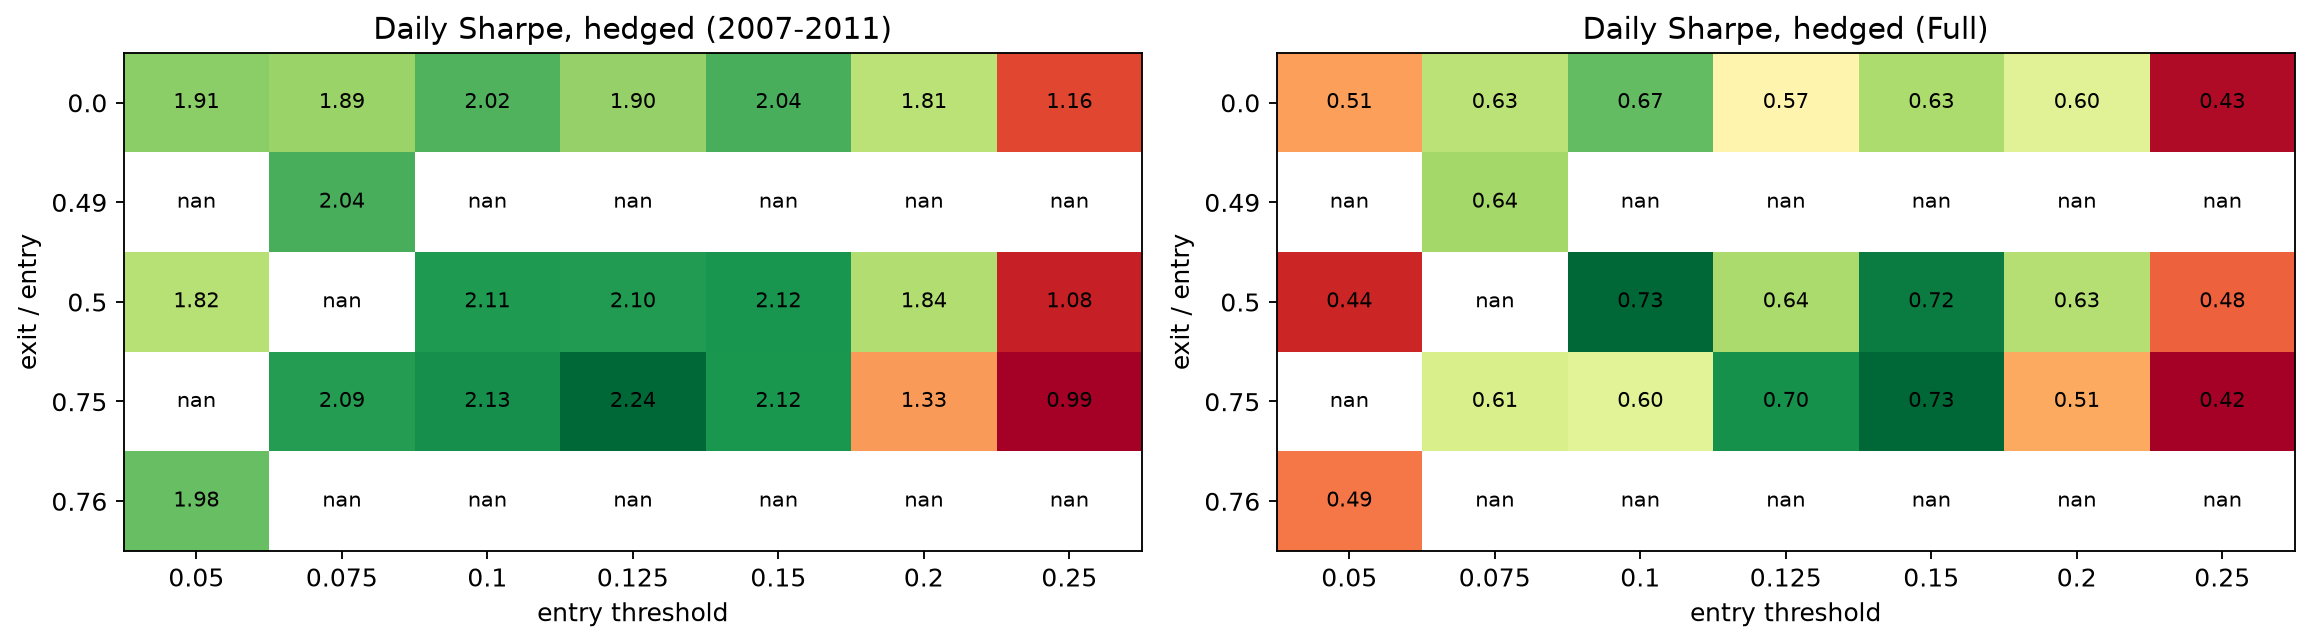

In [35]:
grid = {}
for en in [0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25]:
    for ex_frac in [0.0, 0.5, 0.75]:
        grid[f'entry {en:.3f} / exit {en * ex_frac:.3f}'] = dict(entry_short=en, entry_long=en,
                                                                 exit_short=en * ex_frac, exit_long=en * ex_frac)
res_thr = run_variants(grid)
show(res_thr)

hm = res_thr.reset_index()
hm.columns = ['period', 'variant'] + list(hm.columns[2:])
hm['entry'] = hm.variant.str.extract(r'entry ([\d.]+)').astype(float)
hm['exit'] = hm.variant.str.extract(r'exit ([\d.]+)').astype(float)
hm['exit_frac'] = (hm['exit'] / hm['entry']).round(2)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, per in zip(axes, ['2007-2011', 'Full']):
    pv = hm[hm.period == per].pivot(index='exit_frac', columns='entry', values='daily Sharpe').astype(float)
    im = ax.imshow(pv.values, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(pv.columns))); ax.set_xticklabels(pv.columns)
    ax.set_yticks(range(len(pv.index))); ax.set_yticklabels(pv.index)
    for (r, c), v in np.ndenumerate(pv.values):
        ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=9)
    ax.set_xlabel('entry threshold'); ax.set_ylabel('exit / entry'); ax.set_title(f'Daily Sharpe, hedged ({per})'); ax.grid(False)
plt.tight_layout(); plt.show()

### 14.2 Asymmetric thresholds (short-only, long-only, different entry levels)

In [36]:
asym = {
    'paper (both sides)': {},
    'short only':          dict(entry_long=99),
    'long only':           dict(entry_short=99),
    'short 0.10 / long 0.20': dict(entry_long=0.20, exit_long=0.10),
    'short 0.05 / long 0.10': dict(entry_short=0.05, exit_short=0.025),
    'short 0.15 / long 0.15': dict(entry_short=0.15, entry_long=0.15, exit_short=0.075, exit_long=0.075),
}
show(run_variants(asym))

,,n short,n long,mean short,mean long,mean all,Sortino all,total $,daily Sharpe,max DD $,% days in mkt
2007-2011,paper (both sides),65,33,739,"1,543","1,010",1.30,"98,946",2.11,"-7,513",47%
Full,paper (both sides),269,83,254,727,366,0.34,"128,725",0.73,"-27,465",48%
2007-2011,short only,65,0,739,nan,739,1.04,"48,039",1.81,"-5,308",33%
Full,short only,269,0,254,nan,254,0.26,"68,349",0.66,"-25,032",40%
2007-2011,long only,0,34,nan,"1,501","1,501",1.70,"51,036",1.31,"-10,582",14%
Full,long only,0,86,nan,655,655,0.46,"56,343",0.39,"-27,829",8%
2007-2011,short 0.10 / long 0.20,65,18,739,"2,737","1,172",1.62,"97,312",2.19,"-7,719",41%
Full,short 0.10 / long 0.20,269,42,254,"1,447",415,0.33,"129,114",0.79,"-27,080",45%
2007-2011,short 0.05 / long 0.10,108,33,417,"1,541",680,0.79,"95,941",1.92,"-9,575",64%
Full,short 0.05 / long 0.10,437,83,72,704,173,0.17,"90,110",0.47,"-43,850",69%


### 14.3 Holding period and contract choice

In [37]:
hold = {f'max hold {h}d': dict(max_hold=h) for h in [3, 5, 7, 9]}
hold.update({f'min TTS {t} / max hold {t - 1}': dict(min_tts=t, max_hold=t - 1) for t in [5, 15, 20]})
hold['min TTS 15 / max hold 9'] = dict(min_tts=15, max_hold=9)
hold['same-day re-entry'] = dict(same_day_reentry=True)
show(run_variants(hold))

,,n short,n long,mean short,mean long,mean all,Sortino all,total $,daily Sharpe,max DD $,% days in mkt
2007-2011,max hold 3d,117,54,187,491,283,0.40,"48,331",1.26,"-8,090",37%
Full,max hold 3d,515,128,15,113,34,0.04,"22,088",0.15,"-52,617",37%
2007-2011,max hold 5d,87,41,457,"1,041",644,0.86,"82,440",1.98,"-6,702",42%
Full,max hold 5d,380,99,83,322,133,0.11,"63,508",0.37,"-55,236",43%
2007-2011,max hold 7d,76,35,581,"1,136",756,0.91,"83,887",1.74,"-9,171",45%
Full,max hold 7d,317,92,151,132,147,0.12,"60,129",0.33,"-66,280",47%
2007-2011,max hold 9d,65,33,739,"1,543","1,010",1.30,"98,946",2.11,"-7,513",47%
Full,max hold 9d,269,83,254,727,366,0.34,"128,725",0.73,"-27,465",48%
2007-2011,min TTS 5 / max hold 4,113,50,334,980,532,0.61,"86,729",1.62,"-8,942",44%
Full,min TTS 5 / max hold 4,514,137,18,354,88,0.09,"57,569",0.30,"-59,665",46%


### 14.4 Execution lag and transaction costs
`exec_lag = 1` trades at the next day's settle after the signal is observed. This is the realistic setting for an end-of-day process and removes any same-close synchronisation advantage.

In [38]:
execc = {'lag 0 (paper)': {}, 'lag 1': dict(exec_lag=1), 'lag 2': dict(exec_lag=2)}
execc.update({f'VX cost {c:.2f}/side': dict(vx_cost=c) for c in [0.0, 0.025, 0.05, 0.10, 0.15]})
execc['lag 1 + VX cost 0.10'] = dict(exec_lag=1, vx_cost=0.10)
res_exec = run_variants(execc)
show(res_exec)

,,n short,n long,mean short,mean long,mean all,Sortino all,total $,daily Sharpe,max DD $,% days in mkt
2007-2011,lag 0 (paper),65,33,739,"1,543","1,010",1.30,"98,946",2.11,"-7,513",47%
Full,lag 0 (paper),269,83,254,727,366,0.34,"128,725",0.73,"-27,465",48%
2007-2011,lag 1,65,33,624,"1,544",934,1.26,"91,525",1.98,"-12,127",47%
Full,lag 1,270,83,161,282,190,0.16,"67,001",0.37,"-69,275",48%
2007-2011,lag 2,63,33,698,"1,583","1,002",1.42,"96,179",2.00,"-7,208",47%
Full,lag 2,268,81,258,612,340,0.36,"118,710",0.65,"-39,190",48%
2007-2011,VX cost 0.00/side,65,33,859,"1,663","1,130",1.55,"110,706",2.36,"-7,296",47%
Full,VX cost 0.00/side,269,83,374,847,486,0.47,"170,965",0.98,"-21,642",48%
2007-2011,VX cost 0.03/side,65,33,809,"1,613","1,080",1.44,"105,806",2.26,"-7,373",47%
Full,VX cost 0.03/side,269,83,324,797,436,0.41,"153,365",0.87,"-23,942",48%


### 14.5 Hedge model: estimation window, in-sample hedge, no hedge

In [39]:
o_full, _ = fit_eq3(HEDGE_EST_START, None)
o_paper, _ = fit_eq3(HEDGE_EST_START, PAPER_END)
hedge_var = {
    'expanding OOS (paper)': {},
    'rolling 252d': dict(window=252),
    'rolling 504d': dict(window=504),
    'rolling 756d': dict(window=756),
    'in-sample beta 2006-11': dict(beta=o_paper.params.values),
    'in-sample beta full': dict(beta=o_full.params.values),
    'paper beta (-.018,-.717,.011)': dict(beta=np.array([-0.018, -0.717, 0.011])),
    'unhedged': dict(col='unhedged'),
}
show(run_variants(hedge_var))

,,n short,n long,mean short,mean long,mean all,Sortino all,total $,daily Sharpe,max DD $,% days in mkt
2007-2011,expanding OOS (paper),65,33,739,"1,543","1,010",1.30,"98,946",2.11,"-7,513",47%
Full,expanding OOS (paper),269,83,254,727,366,0.34,"128,725",0.73,"-27,465",48%
2007-2011,rolling 252d,65,33,724,"1,674","1,044",1.35,"102,316",2.20,"-7,582",47%
Full,rolling 252d,269,83,240,773,365,0.35,"128,607",0.74,"-26,820",48%
2007-2011,rolling 504d,65,33,743,"1,601","1,032",1.34,"101,130",2.18,"-7,502",47%
Full,rolling 504d,269,83,238,760,362,0.34,"127,271",0.72,"-28,060",48%
2007-2011,rolling 756d,65,33,742,"1,543","1,012",1.31,"99,177",2.11,"-7,510",47%
Full,rolling 756d,269,83,249,734,363,0.34,"127,849",0.72,"-27,505",48%
2007-2011,in-sample beta 2006-11,65,33,729,"1,471",979,1.31,"95,910",2.14,"-7,419",47%
Full,in-sample beta 2006-11,269,83,250,687,353,0.32,"124,243",0.71,"-27,503",48%


### 14.6 Sub-period stability (paper rules)

In [40]:
eras = {'2007-06/2009': (PAPER_START, PAPER_H1_END), '07/2009-2011': (PAPER_H2_START, PAPER_END),
        '2012-2014': ('2012-01-01', '2014-12-31'), '2015-2017': ('2015-01-01', '2017-12-31'),
        '2018-2019': ('2018-01-01', '2019-12-31'), '2020-2021': ('2020-01-01', '2021-12-31'),
        '2022-2023': ('2022-01-01', '2023-12-31'), '2024-latest': ('2024-01-01', None)}
res_era = {}
for per, (a, b) in eras.items():
    if pd.Timestamp(a) > dates[-1]:
        continue
    t, d = run_backtest(mkt, PARAMS, a, b)
    res_era[(per, 'hedged')] = summarize(t, d, 'hedged')
    res_era[(per, 'unhedged')] = summarize(t, d, 'unhedged')
show(pd.DataFrame(res_era).T)

### 14.7 Bootstrap p-values across periods (paper method)

In [41]:
rng = np.random.default_rng(SEED)
prow = []
for per, (a, b) in {'2007-2011': (PAPER_START, PAPER_END), '2012-latest': ('2012-01-01', None),
                    'Full': (PAPER_START, None)}.items():
    t, _ = run_backtest(mkt, PARAMS, a, b)
    tab, _ = trade_table(t, mkt, a, b, rng=rng)
    for side in ['Short', 'Long']:
        for leg in ['Hedged', 'Unhedged']:
            if (side, leg) in tab:
                r = tab[(side, leg)]
                prow.append({'period': per, 'side': side, 'leg': leg, 'n': int(r['N']),
                             'mean $': r['Mean'], 'p-value': r['P-value'], 'Sortino': r['Sortino']})
display(pd.DataFrame(prow).set_index(['period', 'side', 'leg']).style.format({'mean $': '{:,.0f}', 'p-value': '{:.3f}', 'Sortino': '{:.2f}'}))

---
## 15. Hedge effectiveness
The paper reports a correlation of about −0.7 between the VX and ES legs and a much lower downside volatility for the hedged position.

2007-2011


,"corr(VX, ES) per trade",semi-sd unhedged,semi-sd hedged,semi-sd reduction,sd reduction,mean hedge cost $
Short,-0.67,1287.22,710.95,0.45,0.26,-51.02
Long,-0.87,1786.96,897.14,0.50,0.37,85.94
Daily (in trade),-0.84,--,--,--,0.44,--


Full sample


,"corr(VX, ES) per trade",semi-sd unhedged,semi-sd hedged,semi-sd reduction,sd reduction,mean hedge cost $
Short,-0.67,1324.80,960.43,0.28,0.26,-158.85
Long,-0.86,2356.62,1406.06,0.40,0.36,294.76
Daily (in trade),-0.79,--,--,--,0.37,--


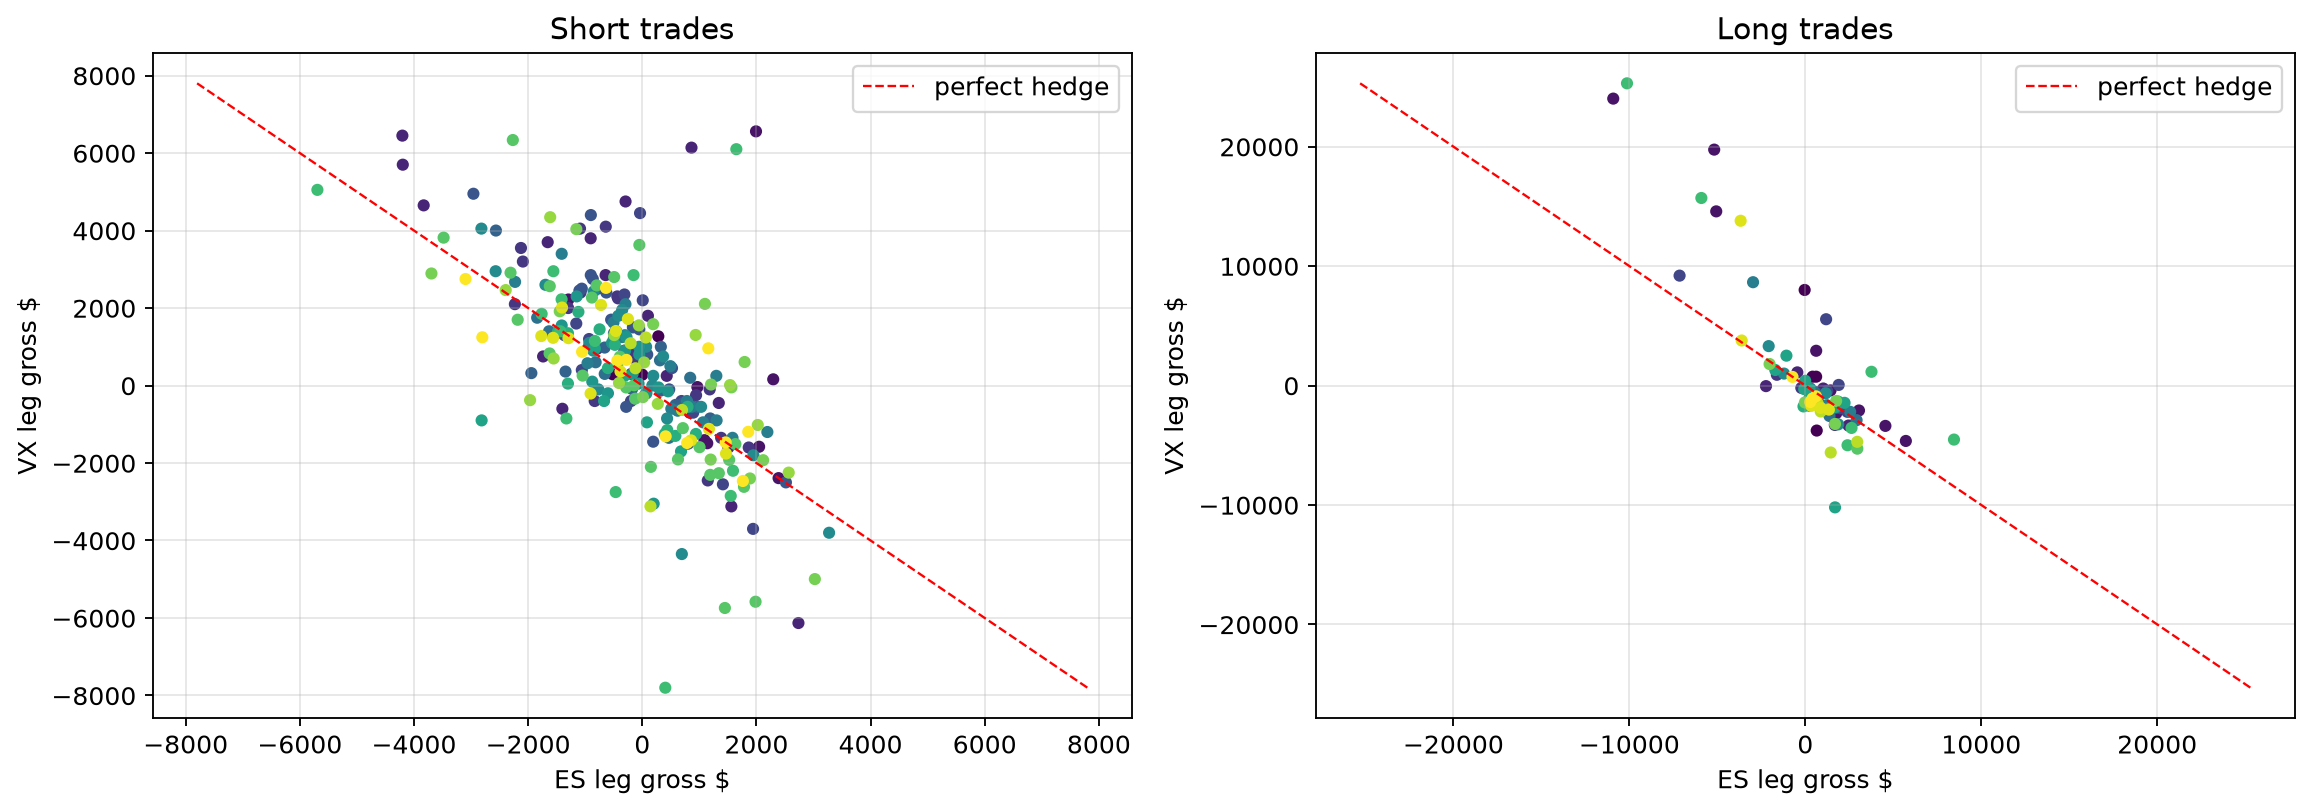

In [42]:
def hedge_eff(tr, dl, lab):
    rows = {}
    for side in ['Short', 'Long']:
        t = tr[tr.side == side]
        if len(t) < 3: continue
        rows[side] = {'corr(VX, ES) per trade': np.corrcoef(t.vx_gross, t.es_gross)[0, 1],
                      'semi-sd unhedged': semi_sd(t.unhedged), 'semi-sd hedged': semi_sd(t.hedged),
                      'semi-sd reduction': 1 - semi_sd(t.hedged) / semi_sd(t.unhedged),
                      'sd reduction': 1 - t.hedged.std() / t.unhedged.std(),
                      'mean hedge cost $': t.hedge.mean()}
    m = dl.pos != 0
    rows['Daily (in trade)'] = {'corr(VX, ES) per trade': np.corrcoef(dl.vx[m], dl.es[m])[0, 1],
                                'sd reduction': 1 - dl.hedged[m].std() / dl.unhedged[m].std()}
    print(lab); display(pd.DataFrame(rows).T.style.format('{:.2f}', na_rep='--'))

hedge_eff(tr_paper, dl_paper, '2007-2011')
hedge_eff(tr_full, dl_full, 'Full sample')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, side in zip(axes, ['Short', 'Long']):
    t = tr_full[tr_full.side == side]
    ax.scatter(t.es_gross, t.vx_gross, c=t.exit.dt.year, cmap='viridis', s=18)
    lim = np.nanmax(np.abs(t[['es_gross', 'vx_gross']].values)) if len(t) else 1
    ax.plot([-lim, lim], [lim, -lim], 'r--', lw=1, label='perfect hedge')
    ax.set_xlabel('ES leg gross $'); ax.set_ylabel('VX leg gross $'); ax.set_title(f'{side} trades'); ax.legend()
plt.tight_layout(); plt.show()

---
## 16. Summary

In [43]:
def line(lbl, tr, dl):
    s = summarize(tr, dl, 'hedged'); u = summarize(tr, dl, 'unhedged')
    return {'sample': lbl, 'trades': len(tr), 'mean hedged $': s['mean all'], 'mean unhedged $': u['mean all'],
            'total hedged $': s['total $'], 'Sortino hedged': s['Sortino all'], 'Sortino unhedged': u['Sortino all'],
            'daily Sharpe hedged': s['daily Sharpe'], 'daily Sharpe unhedged': u['daily Sharpe'],
            'maxDD hedged $': s['max DD $'], 'maxDD unhedged $': u['max DD $']}

lag1 = run_backtest(mkt, dict(exec_lag=1), PAPER_START, None)
summary = pd.DataFrame([line('2007-2011 (paper replication)', tr_paper, dl_paper),
                        line('2012-latest (post-publication)', tr_post, dl_post),
                        line('Full sample', tr_full, dl_full),
                        line('Full sample, exec lag 1', *lag1)]).set_index('sample')
display(summary.style.format('{:,.2f}').format({c: '{:,.0f}' for c in summary.columns if '$' in c or c == 'trades'}))

print('Paper, 2007-2011: short hedged $792 (p=.003, Sortino 1.26), long hedged $1,018 (p<.001, Sortino 1.03), '
      'cumulative $89,835')

,trades,mean hedged $,mean unhedged $,total hedged $,Sortino hedged,Sortino unhedged,daily Sharpe hedged,daily Sharpe unhedged,maxDD hedged $,maxDD unhedged $
sample,,,,,,,,,,
2007-2011 (paper replication),98,"1,010","1,015","98,946",1.296696,0.688047,2.105878,1.190082,"-7,513","-16,842"
2012-latest (post-publication),255,110,177,"28,086",0.093576,0.105024,0.218545,0.234959,"-27,465","-36,519"
Full sample,352,366,418,"128,725",0.337927,0.256482,0.732058,0.530224,"-27,465","-36,519"
"Full sample, exec lag 1",353,190,368,"67,001",0.157739,0.191753,0.366025,0.453664,"-69,275","-76,986"


Paper, 2007-2011: short hedged $792 (p=.003, Sortino 1.26), long hedged $1,018 (p<.001, Sortino 1.03), cumulative $89,835


### Caveats and notes

1. **Prices and synchronicity.** The paper trades at the first quote after 3:00 pm CT with a spread ≤ 0.10 and measures VIX and ES in the same minute. Here, VX daily settlements are combined with the VIX close and ES closes.
   * ES settles earlier than VX/VIX, so hedge-ratio regressions are somewhat noisier and hedge P&L is slightly misaligned.
   * With `exec_lag = 0`, the signal and the fill come from the same close, as in the paper. This is feasible only with intraday monitoring near the close. `exec_lag = 1` is the implementable end-of-day version.
2. **Costs.** Spreads are modelled, not observed. `VX_COST_PER_SIDE = 0.06` roughly matches the paper's ≈ \$140 round trip. Today's front-month VX usually trades one tick (0.05) wide in normal markets, but much wider in stress. `VX_COST_VIX_SCALE` approximates that widening, and Section 14.4 shows sensitivity. Slippage in size, exchange fees and financing on margin are ignored.
3. **ES data.** `ES=F` from Yahoo is an unadjusted continuous contract. Roll gaps are detected against `^GSPC` and replaced. A roll-adjusted series (e.g. Bloomberg `ES1 Index` with ratio/difference adjustment) via `ES_SOURCE = 'csv'` is preferable. Fractional ES contracts are allowed, as in the paper. With one VX lot the rounding error would be large, so a real implementation needs several VX contracts or MES.
4. **2006 burn-in.** If the 2006 contracts are not available, hedge ratios start only after `HEDGE_MIN_OBS` observations, and early-2007 trades are skipped. Compare the trade counts with the paper.
5. **Final settlement (Exhibit 4).** Where the settlement-day row is missing from a file, the VIX open is used as a proxy for the SOQ. The SOQ can differ materially from the VIX open.
6. **Settlement calendar.** Archive-file expiries come from the CBOE rule with an approximate holiday calendar. Check the expiry diagnostic in Section 4.
7. **Capital.** P&L is per 1 VX contract with no compounding. The paper's return-on-margin figures ignore the fact that required margin rises sharply in volatile markets, when long-backwardation trades are open. Treat them as illustrations.
8. **Data errors.** The large-move and F/VIX-ratio screens in Section 6 flag suspicious prints. Inspect the largest-loss and largest-win trades (Section 13) before trusting the tails.